# 🇮🇳📉🇨🇳 Impact of Indian Rupee Depreciation Against Chinese Yuan on India's Trade
---
**Project:** Research Analysis | **Domain:** International Economics & Trade Finance  
**Dataset:** Monthly India–China Trade Data (Jan 2021 – Apr 2026)  
**Variables:** Imports, Exports, Trade Deficit, INR/CNY Exchange Rate  

---
> *"A weaker currency is a double-edged sword — it raises the cost of imports while promising to boost export competitiveness. This study examines how India's rupee depreciation against the Chinese Yuan has shaped the bilateral trade relationship."*

---


## 📦 0. Library Imports & Global Configuration

In [2]:
pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 1.5 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.9 MB 1.8 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.9 MB 1.7 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.9 MB 1.6 MB/s eta 0:00:06
   -------- ------------------------------- 2.1/9.9 MB 1.6 MB/s eta 0:00:05
   ---------- ----------------------------- 2.6/9.9 MB 1.7 MB/s eta 0:00:05
   ----------- ---------------------------- 2.9/9.9 MB 1.7 MB/s eta 0:00:05
   ------------- -------------------------- 3.4/9.9 MB 1.7 MB/s eta 0:00:04
   -------------- ------------------------- 3.7/9.9 MB 1.8 MB/s eta 0:00:04
   ---------------- ----------------------- 4.2/9.9 MB 1.8 MB/s eta 0:00:04
   ------------------- ----------

In [4]:
pip install sklearn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [15 lines of output]
  The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
  rather than 'sklearn' for pip commands.
  
  Here is how to fix this error in the main use cases:
  - use 'pip install scikit-learn' rather than 'pip install sklearn'
  - replace 'sklearn' by 'scikit-learn' in your pip requirements files
    (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
  - if the 'sklearn' package is used by one of your dependencies,
    it would be great if you take some time to track which package uses
    'sklearn' instead of 'scikit-learn' and report it to their issue tracker
  - as a last resort, set the environment variable
    SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
  
  More information is available at
  https://github.com/scikit-learn/sklearn-pypi-package
  [end of output]
  
  note: This error originates f

In [5]:
pip install numpy pandas matplotlib seaborn plotly

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.6 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.1 MB 1.4 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.1 MB 1.4 MB/s eta 0:00:06
   ----- ---------------------------------- 1.0/8.1 MB 831.6 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.1 MB 944.7 kB/s eta 0:00:08
   --------- ------------------------------ 1.8/8.1 MB 1.1 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.1 MB 1.2 MB/s eta 0:00:05
   ------------ --------------------------- 2.6/8.1 MB 1.3 MB/s eta 0:00:05
   --------------- ------------------------ 3.1/8.1 MB 1.4 MB/s eta 0:00:04
   ---------------- ----------------------- 3.4/8.1 MB 1.5 MB/s eta 0:00:04
   -------------------- -----

In [92]:
import plotly.io as pio
pio.renderers.default = "notebook" # or "iframe" if notebook doesn't work

In [93]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, ttest_1samp
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# ── Global plot settings ──
pio.templates.default = "plotly_dark"
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'figure.dpi':       130,
})

PALETTE = ['#58a6ff','#3fb950','#ff7b72','#d2a8ff','#ffa657','#39d353','#f78166']
print("✅ Libraries loaded successfully.")


✅ Libraries loaded successfully.


## 📂 1. Data Loading & Preparation

In [94]:

# ── Load dataset ──
df = pd.read_excel('yuan_project_data.xlsx', parse_dates=['Month'])
df.sort_values('Month', inplace=True)
df.reset_index(drop=True, inplace=True)

# Rename for convenience
df.rename(columns={
    'Import (USDmn)':         'Imports',
    'Export (USDmn)':         'Exports',
    'Trade Deficit (USDmn)':  'Trade_Deficit_Raw',
    'Rs Per Yuan':             'Exchange_Rate'
}, inplace=True)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDate range:", df['Month'].min().strftime('%b %Y'), "→", df['Month'].max().strftime('%b %Y'))
print("\nMissing values:\n", df.isnull().sum())


Shape: (64, 5)

Columns: ['Month', 'Imports', 'Exports', 'Trade_Deficit_Raw', 'Exchange_Rate']

Date range: Jan 2021 → Apr 2026

Missing values:
 Month                0
Imports              0
Exports              0
Trade_Deficit_Raw    0
Exchange_Rate        0
dtype: int64


In [95]:

print("=== HEAD ===")
display(df.head())
print("\n=== TAIL ===")
display(df.tail())
print("\n=== DATA TYPES ===")
display(df.dtypes.to_frame('dtype'))


=== HEAD ===


,Month,Imports,Exports,Trade_Deficit_Raw,Exchange_Rate
0,2021-01-01,"6,682.70","1,558.61","5,124.09",11.31
1,2021-02-01,"6,322.27","1,715.50","4,606.77",11.33
2,2021-03-01,"6,845.35","2,650.18","4,195.17",11.18
3,2021-04-01,"6,513.34","2,290.36","4,222.98",11.45
4,2021-05-01,"7,138.63","2,160.48","4,978.15",11.37



=== TAIL ===


,Month,Imports,Exports,Trade_Deficit_Raw,Exchange_Rate
59,2025-12-01,"11,691.17","2,036.90","9,654.27",12.83
60,2026-01-01,"12,231.00","1,633.98","10,597.02",13.21
61,2026-02-01,"11,382.01","1,670.93","9,711.08",13.30
62,2026-03-01,"12,075.48","1,936.34","10,139.14",13.65
63,2026-04-01,"11,971.78","1,771.32","10,200.46",13.88



=== DATA TYPES ===


,dtype
Month,datetime64[us]
Imports,float64
Exports,float64
Trade_Deficit_Raw,float64
Exchange_Rate,float64


## 🔧 2. Derived Variables

In [96]:

# ── Derived variables ──
df['Net_Exports']          = df['Exports'] - df['Imports']
df['Trade_Deficit']        = df['Imports'] - df['Exports']
df['Trade_Deficit_Rate']   = (df['Trade_Deficit'] / df['Imports']) * 100
df['Total_Trade']          = df['Imports'] + df['Exports']

df['Export_Growth']        = df['Exports'].pct_change() * 100
df['Import_Growth']        = df['Imports'].pct_change() * 100
df['INR_Depreciation']     = df['Exchange_Rate'].pct_change() * 100

# Rolling statistics (3, 6, 12 months)
for w in [3, 6, 12]:
    df[f'Imports_MA{w}']   = df['Imports'].rolling(w).mean()
    df[f'Exports_MA{w}']   = df['Exports'].rolling(w).mean()
    df[f'FX_MA{w}']        = df['Exchange_Rate'].rolling(w).mean()
    df[f'Deficit_MA{w}']   = df['Trade_Deficit'].rolling(w).mean()

df['FX_Volatility']        = df['Exchange_Rate'].rolling(6).std()
df['Import_Volatility']    = df['Imports'].rolling(6).std()

# Indexed series (base = 100 at first observation)
for col in ['Imports','Exports','Exchange_Rate','Trade_Deficit','Total_Trade']:
    df[f'{col}_Idx'] = (df[col] / df[col].iloc[0]) * 100

# Period labels
def get_period(d):
    if d < pd.Timestamp('2022-01-01'):  return 'Corona (2021)'
    elif d < pd.Timestamp('2026-01-01'): return 'Post-Corona (2022-25)'
    else: return 'Recent (2026)'

df['Period'] = df['Month'].apply(get_period)

# Last 4 months
last4 = df.tail(4).copy()

print("✅ Derived variables created. Total columns:", len(df.columns))
display(df[['Month','Imports','Exports','Net_Exports','Trade_Deficit',
            'Trade_Deficit_Rate','Exchange_Rate','INR_Depreciation']].head(8))


✅ Derived variables created. Total columns: 32


,Month,Imports,Exports,Net_Exports,Trade_Deficit,Trade_Deficit_Rate,Exchange_Rate,INR_Depreciation
0,2021-01-01,"6,682.70","1,558.61","-5,124.09","5,124.09",76.68,11.31,NaN
1,2021-02-01,"6,322.27","1,715.50","-4,606.77","4,606.77",72.87,11.33,0.18
2,2021-03-01,"6,845.35","2,650.18","-4,195.17","4,195.17",61.28,11.18,-1.32
3,2021-04-01,"6,513.34","2,290.36","-4,222.98","4,222.98",64.84,11.45,2.42
4,2021-05-01,"7,138.63","2,160.48","-4,978.15","4,978.15",69.74,11.37,-0.70
5,2021-06-01,"6,986.72","2,298.04","-4,688.68","4,688.68",67.11,11.49,1.06
6,2021-07-01,"7,038.66","2,141.51","-4,897.15","4,897.15",69.58,11.50,0.09
7,2021-08-01,"6,493.43","1,699.47","-4,793.96","4,793.96",73.83,11.35,-1.30


## 📊 3. Descriptive Statistics

In [97]:

core_cols = ['Imports','Exports','Net_Exports','Trade_Deficit',
             'Trade_Deficit_Rate','Exchange_Rate','INR_Depreciation',
             'Export_Growth','Import_Growth','Total_Trade']

desc = df[core_cols].describe().T
desc['skewness'] = df[core_cols].skew()
desc['kurtosis'] = df[core_cols].kurtosis()
pd.options.display.float_format = '{:,.2f}'.format
display(desc.style.background_gradient(cmap='Blues', axis=1))


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Imports,64.000000,8933.045781,1500.995945,6322.270000,7847.775000,8710.510000,9783.405000,12231.000000,0.379882,-0.556082
Exports,64.000000,1478.808438,360.812275,908.600000,1219.250000,1418.295000,1641.847500,2650.180000,1.020140,1.067807
Net_Exports,64.000000,-7454.237344,1604.839531,-10597.020000,-8513.427500,-7344.815000,-6540.362500,-4195.170000,0.088659,-0.595644
Trade_Deficit,64.000000,7454.237344,1604.839531,4195.170000,6540.362500,7344.815000,8513.427500,10597.020000,-0.088659,-0.595644
Trade_Deficit_Rate,64.000000,82.797341,6.132787,61.284960,80.772225,84.419496,86.673974,90.838158,-1.629105,2.768176
Exchange_Rate,64.000000,11.836562,0.547854,11.180000,11.497500,11.720000,11.917500,13.880000,2.034214,4.419017
INR_Depreciation,63.000000,0.337474,1.559637,-3.263598,-0.739631,0.427350,1.221231,4.385965,0.048204,-0.019682
Export_Growth,63.000000,1.186647,14.529277,-28.258981,-7.641125,-0.008930,10.152516,54.484407,0.821423,1.926478
Import_Growth,63.000000,1.346098,9.287251,-16.799683,-6.187291,0.705424,8.544583,26.568855,0.230098,-0.459943
Total_Trade,64.000000,10411.854219,1480.148212,8037.770000,9298.462500,10206.770000,11215.412500,14011.820000,0.769443,-0.001519


---
## 📈 PART 1 — Individual Time Series Analysis
Each key variable plotted over the full study period with moving averages, peaks/troughs, and annotations.


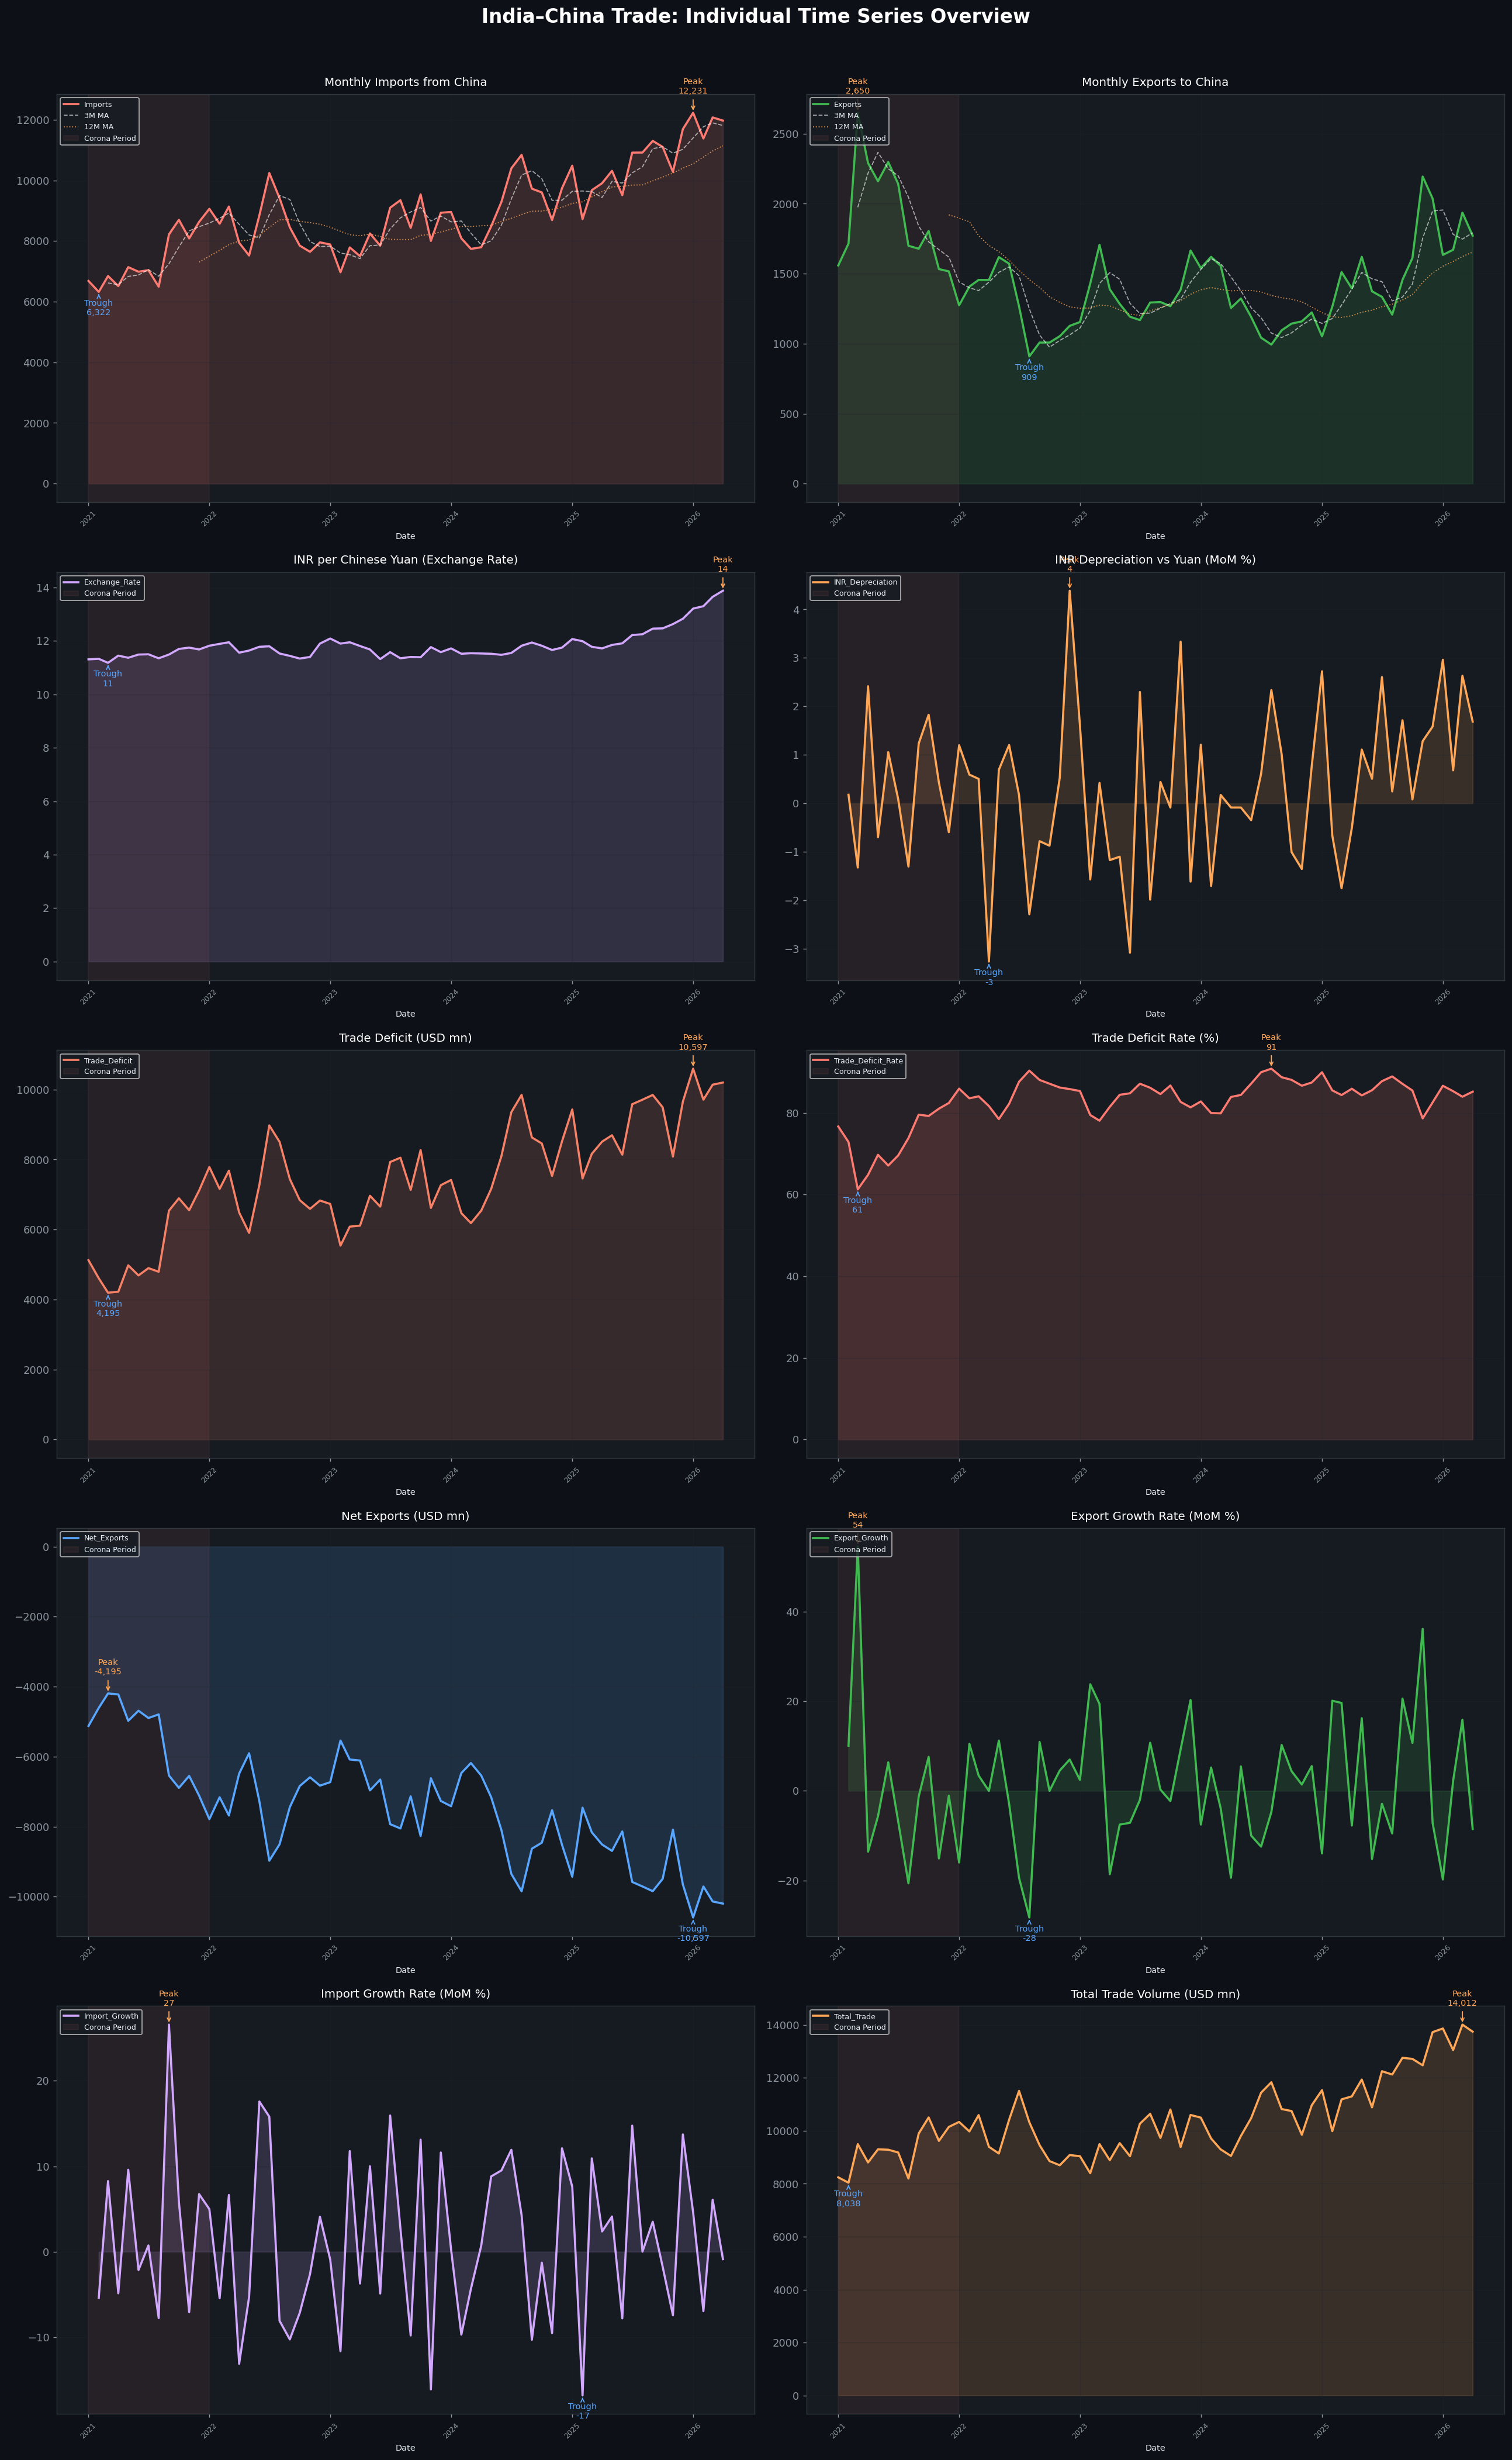


📌 Economic Interpretation:
• Imports from China have shown a persistent upward trend, crossing USD 12bn/month in 2026.
• Exports to China remain structurally weak (~USD 1-2bn/month), widening the deficit.
• Exchange rate (INR/CNY) has depreciated from ~11.3 to ~13.9 — a ~23% weakening of the rupee.
• Despite rupee depreciation, exports have NOT responded positively — suggesting supply-side constraints.


In [98]:

# Helper: annotate peaks and troughs
def annotate_extremes(ax, x, y, color_peak='#ffa657', color_trough='#58a6ff'):
    peak_i  = y.idxmax()
    trough_i = y.idxmin()
    ax.annotate(f'Peak\n{y[peak_i]:,.0f}',
                xy=(x[peak_i], y[peak_i]),
                xytext=(0, 18), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color=color_peak),
                color=color_peak, fontsize=8, ha='center')
    ax.annotate(f'Trough\n{y[trough_i]:,.0f}',
                xy=(x[trough_i], y[trough_i]),
                xytext=(0,-22), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color=color_trough),
                color=color_trough, fontsize=8, ha='center')

fig, axes = plt.subplots(5, 2, figsize=(20, 32))
fig.patch.set_facecolor('#0d1117')
plt.suptitle('India–China Trade: Individual Time Series Overview',
             color='white', fontsize=18, fontweight='bold', y=1.01)

plots = [
    ('Imports',          'Monthly Imports from China',          '#ff7b72'),
    ('Exports',          'Monthly Exports to China',            '#3fb950'),
    ('Exchange_Rate',    'INR per Chinese Yuan (Exchange Rate)', '#d2a8ff'),
    ('INR_Depreciation', 'INR Depreciation vs Yuan (MoM %)',    '#ffa657'),
    ('Trade_Deficit',    'Trade Deficit (USD mn)',               '#f78166'),
    ('Trade_Deficit_Rate','Trade Deficit Rate (%)',              '#ff7b72'),
    ('Net_Exports',      'Net Exports (USD mn)',                 '#58a6ff'),
    ('Export_Growth',    'Export Growth Rate (MoM %)',           '#3fb950'),
    ('Import_Growth',    'Import Growth Rate (MoM %)',           '#d2a8ff'),
    ('Total_Trade',      'Total Trade Volume (USD mn)',          '#ffa657'),
]

for ax, (col, title, col_color) in zip(axes.flatten(), plots):
    x = df['Month']
    y = df[col].dropna()
    x_a = df.loc[y.index, 'Month']

    ax.fill_between(x_a, y, alpha=0.15, color=col_color)
    ax.plot(x_a, y, color=col_color, lw=2, label=col)

    # MA overlays
    if col in ['Imports','Exports','Trade_Deficit','Total_Trade','Exchange_Rate']:
        ma_col = col.replace('Imports','Imports').replace('Exports','Exports')
        try:
            ax.plot(x, df[f'{ma_col}_MA3'],  color='white',   lw=1, ls='--', alpha=0.6, label='3M MA')
            ax.plot(x, df[f'{ma_col}_MA12'], color='#ffa657', lw=1, ls=':',  alpha=0.8, label='12M MA')
        except: pass

    annotate_extremes(ax, x_a.reset_index(drop=True), y.reset_index(drop=True))

    # Corona band
    ax.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-12-31'),
               alpha=0.07, color='#ff7b72', label='Corona Period')
    ax.set_title(title, color='white', fontsize=11, pad=8)
    ax.set_xlabel('Date', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ts_overview.png', dpi=130, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("\n📌 Economic Interpretation:\n"
      "• Imports from China have shown a persistent upward trend, crossing USD 12bn/month in 2026.\n"
      "• Exports to China remain structurally weak (~USD 1-2bn/month), widening the deficit.\n"
      "• Exchange rate (INR/CNY) has depreciated from ~11.3 to ~13.9 — a ~23% weakening of the rupee.\n"
      "• Despite rupee depreciation, exports have NOT responded positively — suggesting supply-side constraints.")


---
## 🔄 PART 2 — INR Depreciation vs Trade Variables (Comparative)


In [99]:

fig = make_subplots(
    rows=4, cols=2,
    subplot_titles=[
        'Exchange Rate vs Imports', 'Exchange Rate vs Exports',
        'Exchange Rate vs Trade Deficit', 'Exchange Rate vs Net Exports',
        'Exchange Rate vs Trade Deficit Rate', 'Exchange Rate vs Export Growth',
        'Exchange Rate vs Import Growth', 'Exchange Rate vs Total Trade',
    ],
    specs=[[{"secondary_y": True}]*2]*4,
    vertical_spacing=0.08, horizontal_spacing=0.1
)
fig.update_layout(
    height=1400, template='plotly_dark',
    title_text='🔄 INR/CNY Exchange Rate vs All Trade Variables',
    title_font_size=18,
    plot_bgcolor='#161b22', paper_bgcolor='#0d1117',
    font_color='#e6edf3', showlegend=False
)

pairs = [
    ('Imports','#ff7b72'),('Exports','#3fb950'),
    ('Trade_Deficit','#f78166'),('Net_Exports','#58a6ff'),
    ('Trade_Deficit_Rate','#ffa657'),('Export_Growth','#d2a8ff'),
    ('Import_Growth','#39d353'),('Total_Trade','#79c0ff'),
]
positions = [(1,1),(1,2),(2,1),(2,2),(3,1),(3,2),(4,1),(4,2)]

for (col,clr), (r,c) in zip(pairs, positions):
    d = df[['Month','Exchange_Rate', col]].dropna()
    fig.add_trace(
        go.Scatter(x=d['Month'], y=d[col], name=col,
                   line=dict(color=clr, width=2), fill='tozeroy', fillcolor=clr.replace('ff','22')),
        row=r, col=c, secondary_y=False
    )
    fig.add_trace(
        go.Scatter(x=d['Month'], y=d['Exchange_Rate'], name='Exchange Rate',
                   line=dict(color='#d2a8ff', width=1.5, dash='dot')),
        row=r, col=c, secondary_y=True
    )

fig.show()


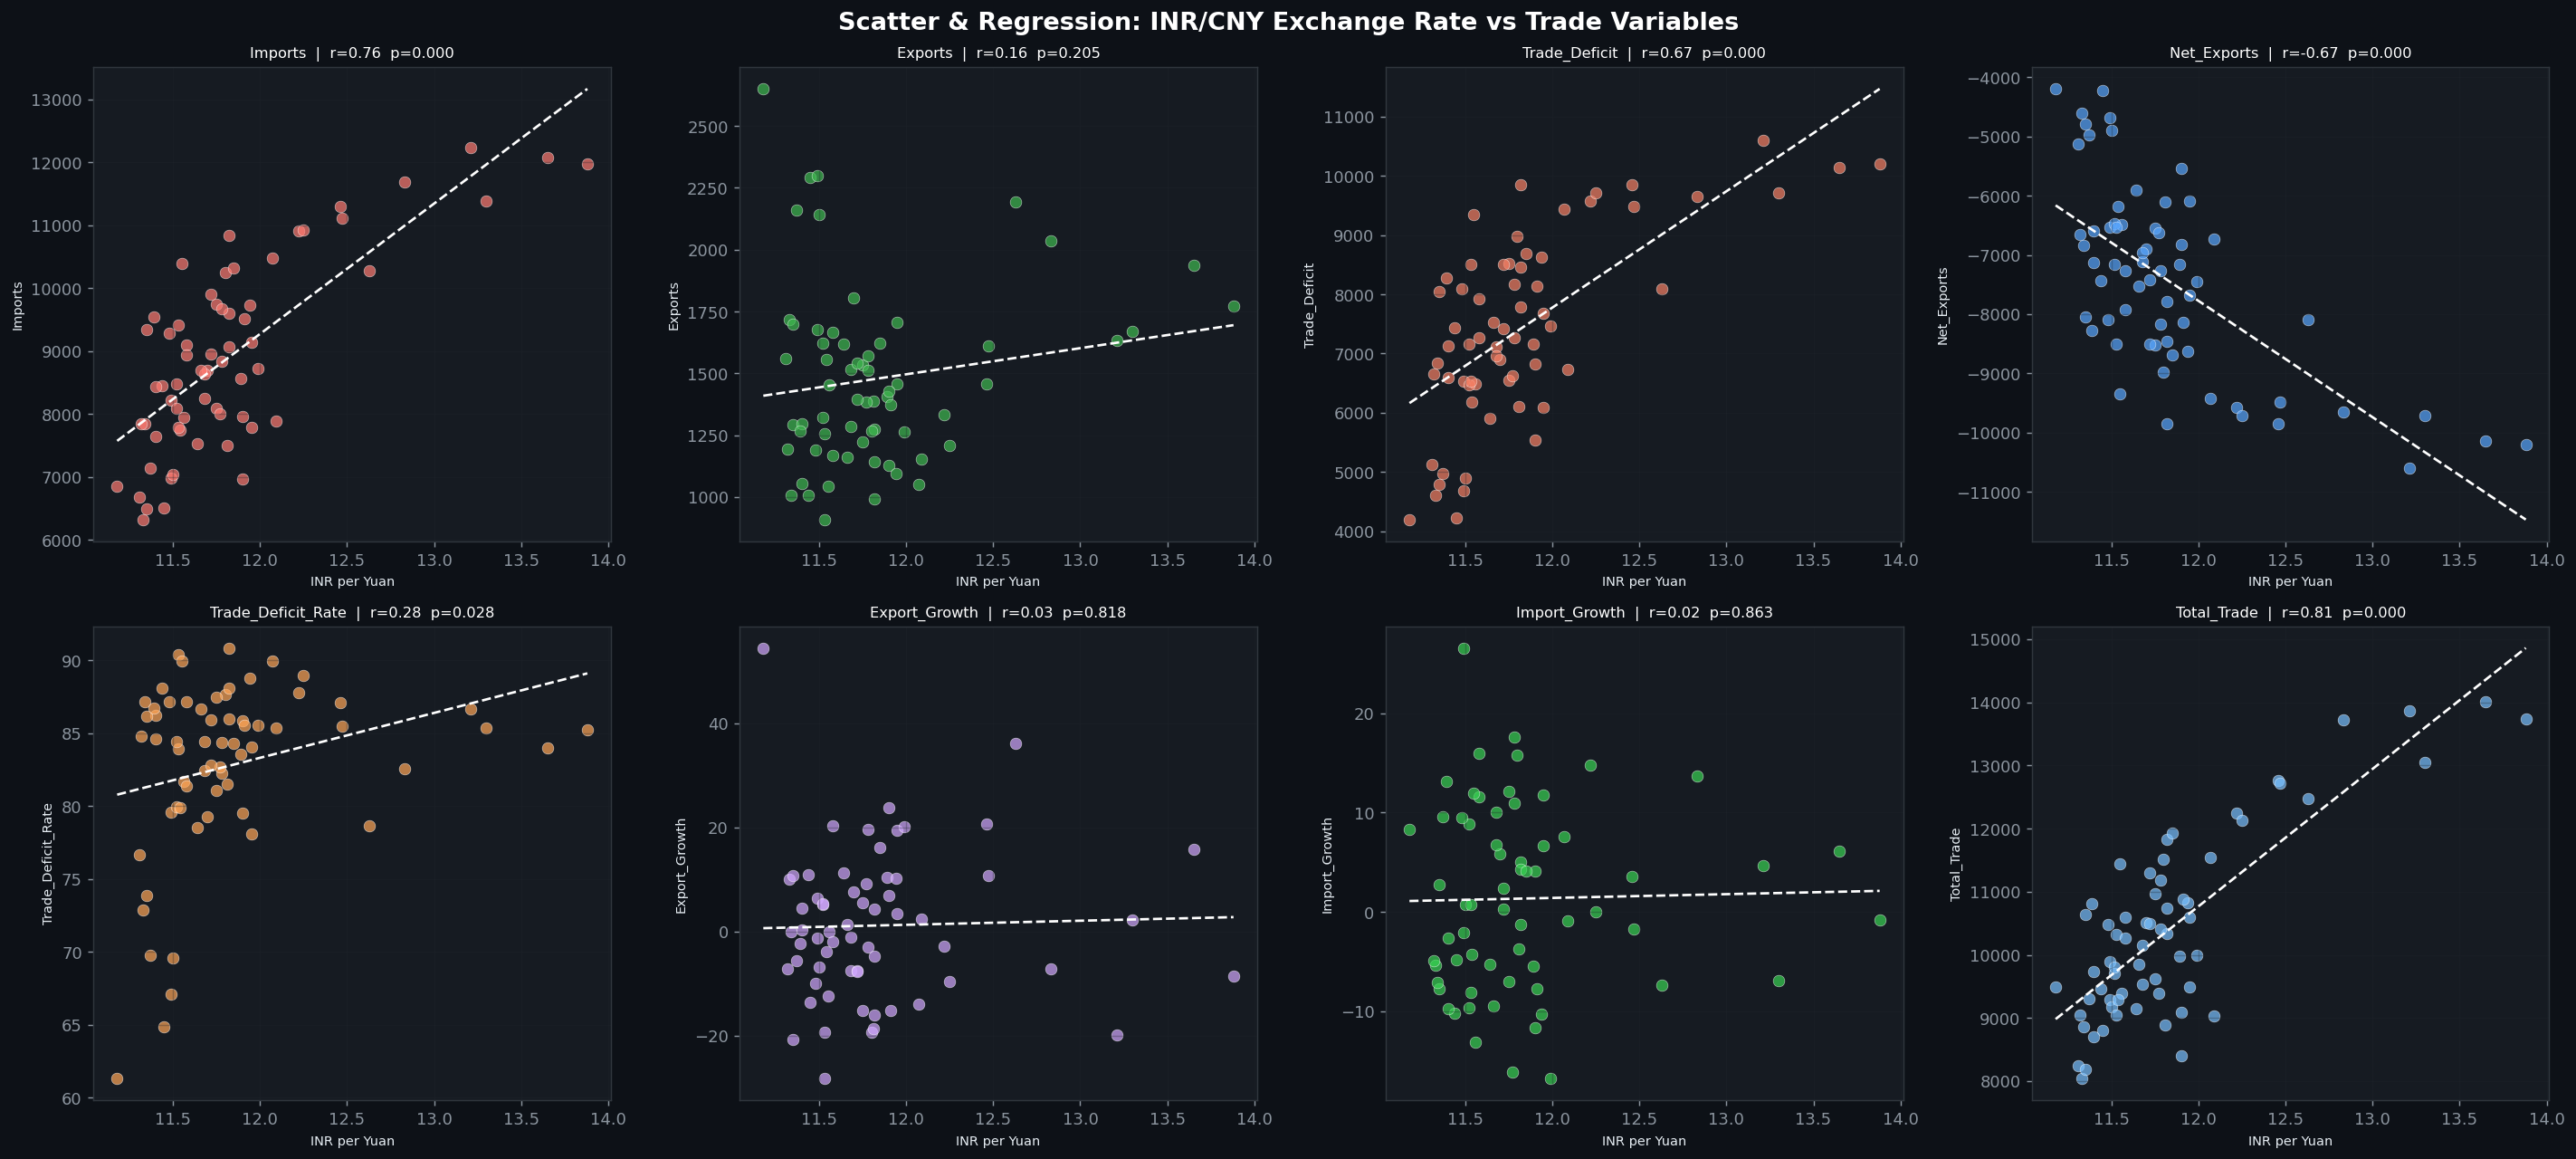

In [100]:

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.patch.set_facecolor('#0d1117')
plt.suptitle('Scatter & Regression: INR/CNY Exchange Rate vs Trade Variables',
             color='white', fontsize=15, fontweight='bold')

trade_vars = [
    ('Imports','#ff7b72'),('Exports','#3fb950'),
    ('Trade_Deficit','#f78166'),('Net_Exports','#58a6ff'),
    ('Trade_Deficit_Rate','#ffa657'),('Export_Growth','#d2a8ff'),
    ('Import_Growth','#39d353'),('Total_Trade','#79c0ff'),
]

for ax, (col, clr) in zip(axes.flatten(), trade_vars):
    d = df[['Exchange_Rate', col]].dropna()
    x, y = d['Exchange_Rate'], d[col]
    ax.scatter(x, y, color=clr, alpha=0.7, s=50, edgecolors='white', lw=0.3)

    # regression line
    m, b, r, p, se = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m*xline+b, color='white', lw=1.5, ls='--')
    ax.set_title(f'{col}  |  r={r:.2f}  p={p:.3f}', color='white', fontsize=9)
    ax.set_xlabel('INR per Yuan', fontsize=8)
    ax.set_ylabel(col, fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_regression.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


---
## 🔥 PART 7 (Subset) — Correlation Heatmap


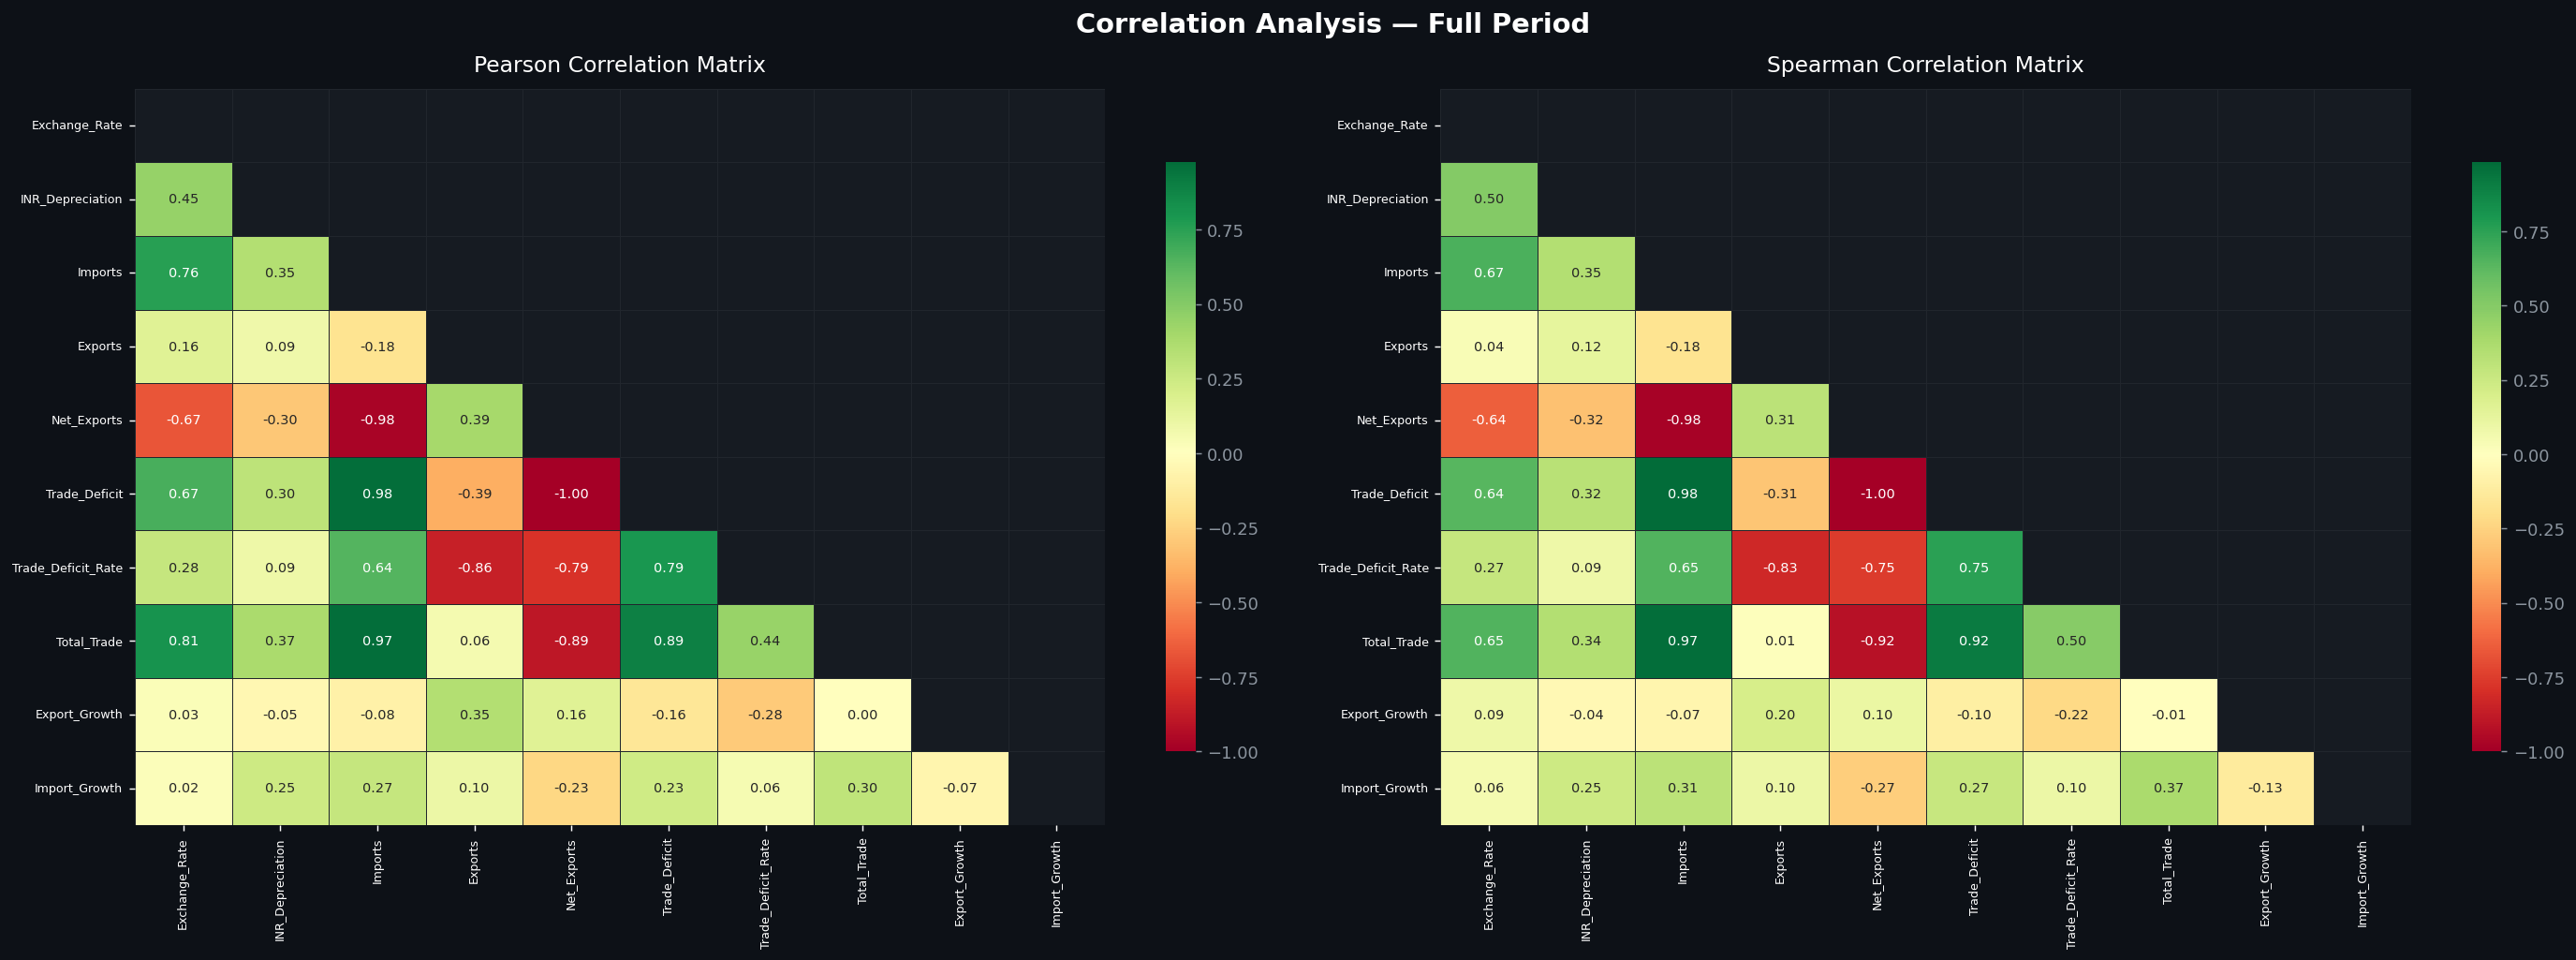


📌 Key correlations with Exchange Rate (Pearson):
  Imports                  : r = +0.756  (p=0.0000)
  Exports                  : r = +0.160  (p=0.2053)
  Trade_Deficit            : r = +0.671  (p=0.0000)
  Net_Exports              : r = -0.671  (p=0.0000)
  Total_Trade              : r = +0.806  (p=0.0000)


In [101]:

corr_cols = ['Exchange_Rate','INR_Depreciation','Imports','Exports',
             'Net_Exports','Trade_Deficit','Trade_Deficit_Rate',
             'Total_Trade','Export_Growth','Import_Growth']

corr = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.patch.set_facecolor('#0d1117')

for ax, (method, label) in zip(axes, [('pearson','Pearson'),('spearman','Spearman')]):
    c = df[corr_cols].corr(method=method)
    mask = np.triu(np.ones_like(c, dtype=bool))
    sns.heatmap(c, ax=ax, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, linewidths=0.5, linecolor='#21262d',
                annot_kws={'size':8}, cbar_kws={'shrink':0.8})
    ax.set_title(f'{label} Correlation Matrix', color='white', fontsize=13, pad=10)
    ax.tick_params(colors='white', labelsize=7)

plt.suptitle('Correlation Analysis — Full Period', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n📌 Key correlations with Exchange Rate (Pearson):")
for c in ['Imports','Exports','Trade_Deficit','Net_Exports','Total_Trade']:
    r, p = pearsonr(df['Exchange_Rate'].dropna(), df[c].dropna())
    print(f"  {c:25s}: r = {r:+.3f}  (p={p:.4f})")


---
## ⚖️ PART 3 — Trade Deficit Deep Dive


In [102]:

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.06,
                    subplot_titles=['Trade Deficit vs Exchange Rate',
                                    'Trade Deficit Rate (%) vs Exchange Rate'])
fig.update_layout(template='plotly_dark', height=700,
                  title_text='Trade Deficit Analysis vs INR Depreciation',
                  title_font_size=16,
                  plot_bgcolor='#161b22', paper_bgcolor='#0d1117')

# Row 1
fig.add_trace(go.Bar(x=df['Month'], y=df['Trade_Deficit'],
                     name='Trade Deficit', marker_color='#ff7b72',
                     opacity=0.7), row=1, col=1)
fig.add_trace(go.Scatter(x=df['Month'], y=df['Deficit_MA6'],
                         name='6M MA Deficit', line=dict(color='#ffa657', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=df['Month'], y=df['Exchange_Rate'],
                         name='Exchange Rate', line=dict(color='#d2a8ff', width=1.5, dash='dot')),
              row=1, col=1, secondary_y=False)

# Row 2
fig.add_trace(go.Scatter(x=df['Month'], y=df['Trade_Deficit_Rate'],
                         fill='tozeroy', fillcolor='rgba(255,123,114,0.2)',
                         line=dict(color='#ff7b72', width=2), name='Deficit Rate %'), row=2, col=1)
fig.add_trace(go.Scatter(x=df['Month'], y=df['Exchange_Rate'],
                         line=dict(color='#d2a8ff', width=1.5, dash='dot'),
                         name='Exchange Rate'), row=2, col=1)

fig.show()

# Period comparison
print("\n=== Trade Deficit by Period ===")
grp = df.groupby('Period')[['Trade_Deficit','Trade_Deficit_Rate','Exchange_Rate']].agg(['mean','max'])
display(grp.style.background_gradient(cmap='Reds'))



=== Trade Deficit by Period ===


---
## 📤 PART 4 — Net Export Analysis


In [103]:

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Net Exports Over Time', 'Net Exports vs Exchange Rate'])
fig.update_layout(template='plotly_dark', height=450,
                  title_text='Net Export Analysis',
                  plot_bgcolor='#161b22', paper_bgcolor='#0d1117')

fig.add_trace(go.Bar(x=df['Month'], y=df['Net_Exports'],
                     marker_color=np.where(df['Net_Exports']<0,'#ff7b72','#3fb950'),
                     name='Net Exports'), row=1, col=1)
fig.add_hline(y=0, line_color='white', line_dash='dash', row=1, col=1)

fig.add_trace(go.Scatter(x=df['Exchange_Rate'], y=df['Net_Exports'],
                         mode='markers',
                         marker=dict(color=df['Net_Exports'], colorscale='RdYlGn',
                                     size=8, showscale=True),
                         name='FX vs Net Exports'), row=1, col=2)

fig.show()

r, p = pearsonr(df['Exchange_Rate'], df['Net_Exports'])
print(f"\nPearson r (Exchange Rate vs Net Exports): {r:.3f}  (p = {p:.4f})")
print("📌 A negative r implies that as INR depreciates (higher INR/CNY), net exports worsen — India's exports do NOT gain competitiveness.")



Pearson r (Exchange Rate vs Net Exports): -0.671  (p = 0.0000)
📌 A negative r implies that as INR depreciates (higher INR/CNY), net exports worsen — India's exports do NOT gain competitiveness.


---
## 🗓️ PART 5 — Period-Specific Analysis

### A. Full Period Overview


In [104]:

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                    subplot_titles=['Exchange Rate (INR/CNY) — Full Period',
                                    'Imports & Exports — Full Period',
                                    'Trade Deficit — Full Period'])
fig.update_layout(template='plotly_dark', height=900,
                  title_text='📅 Full Period Analysis (Jan 2021 – Apr 2026)',
                  plot_bgcolor='#161b22', paper_bgcolor='#0d1117')

# Corona shading using shapes
for row in [1,2,3]:
    fig.add_vrect(x0='2021-01-01', x1='2021-12-31',
                  fillcolor='rgba(255,123,114,0.1)', layer='below', line_width=0, row=row, col=1)

fig.add_trace(go.Scatter(x=df['Month'], y=df['Exchange_Rate'],
                         line=dict(color='#d2a8ff', width=2), name='INR/CNY'), row=1, col=1)
fig.add_trace(go.Scatter(x=df['Month'], y=df['FX_MA12'],
                         line=dict(color='white', width=1, dash='dot'), name='12M MA FX'), row=1, col=1)

fig.add_trace(go.Scatter(x=df['Month'], y=df['Imports'],
                         line=dict(color='#ff7b72', width=2), name='Imports'), row=2, col=1)
fig.add_trace(go.Scatter(x=df['Month'], y=df['Exports'],
                         line=dict(color='#3fb950', width=2), name='Exports'), row=2, col=1)

fig.add_trace(go.Bar(x=df['Month'], y=df['Trade_Deficit'],
                     marker_color='#ffa657', name='Trade Deficit'), row=3, col=1)

fig.show()


### B. Corona Period Analysis (2021)

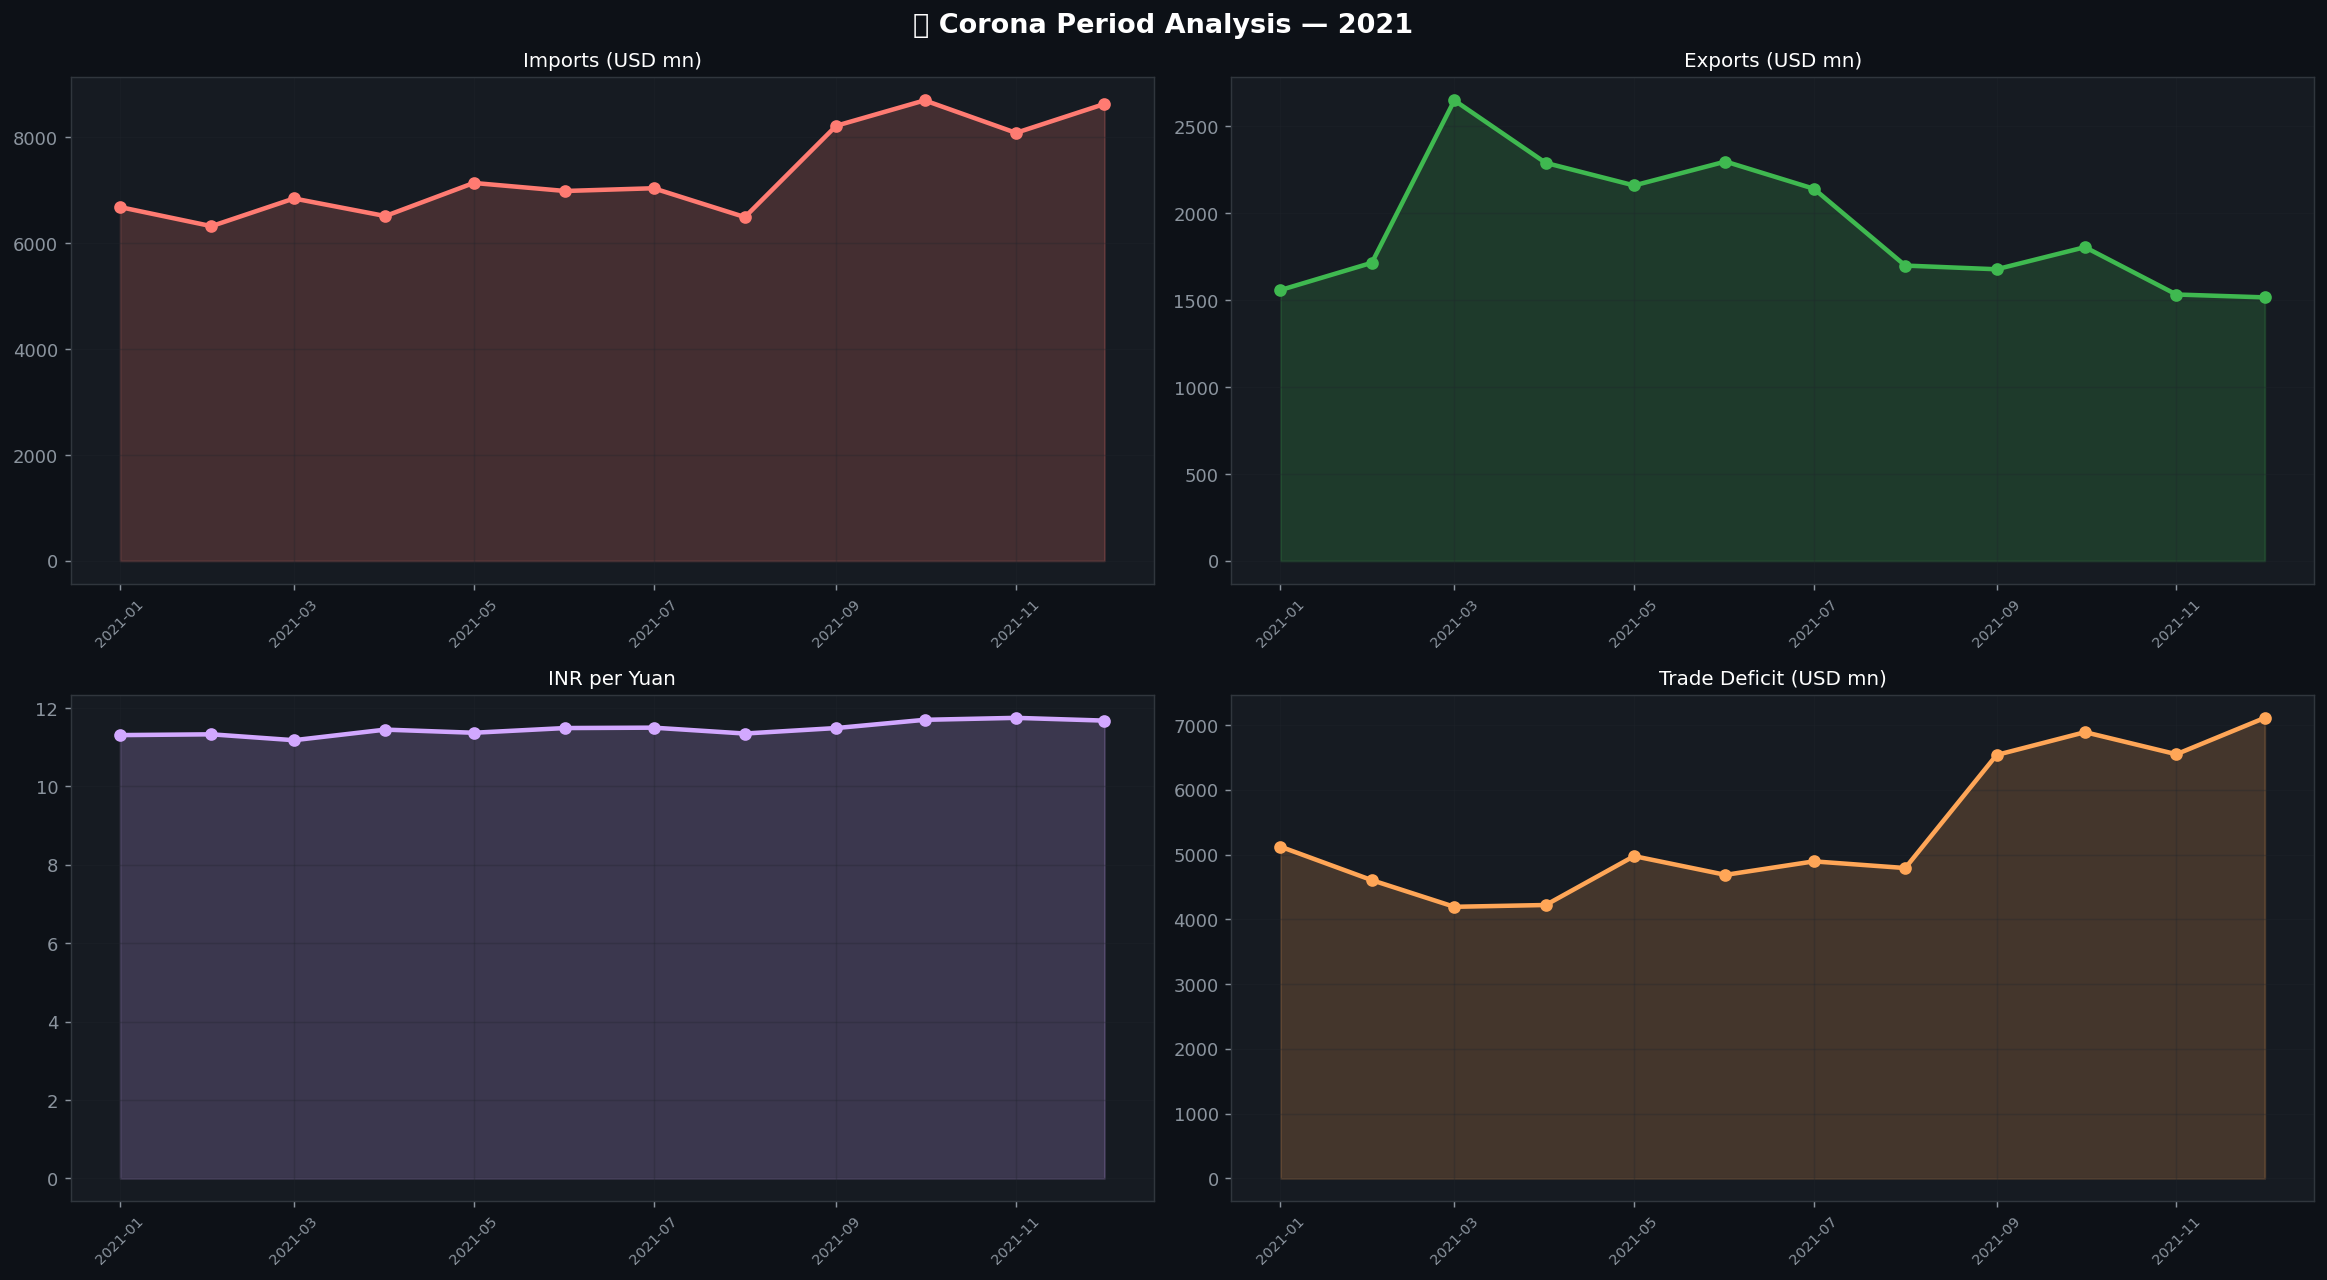


=== Corona Period Summary ===
       Imports  Exports  Trade_Deficit  Exchange_Rate
count    12.00    12.00          12.00          12.00
mean  7,304.45 1,920.59       5,383.85          11.47
std     862.91   372.40       1,071.84           0.17
min   6,322.27 1,516.39       4,195.17          11.18
25%   6,640.36 1,648.29       4,668.20          11.34
50%   7,012.69 1,760.48       4,937.65          11.47
75%   8,118.26 2,192.95       6,543.32          11.54
max   8,698.54 2,650.18       7,113.86          11.75

📌 During 2021: Trade resumed post-lockdown. Imports surged as Chinese factories recovered faster.


In [105]:

corona = df[df['Month'].dt.year == 2021].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.patch.set_facecolor('#0d1117')
plt.suptitle('🦠 Corona Period Analysis — 2021', color='white', fontsize=15, fontweight='bold')

for ax, (col, clr, lbl) in zip(axes.flatten(), [
    ('Imports','#ff7b72','Imports (USD mn)'),
    ('Exports','#3fb950','Exports (USD mn)'),
    ('Exchange_Rate','#d2a8ff','INR per Yuan'),
    ('Trade_Deficit','#ffa657','Trade Deficit (USD mn)'),
]):
    ax.plot(corona['Month'], corona[col], color=clr, lw=2.5, marker='o', ms=6)
    ax.fill_between(corona['Month'], corona[col], alpha=0.2, color=clr)
    ax.set_title(lbl, color='white', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('corona_period.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n=== Corona Period Summary ===")
print(corona[['Imports','Exports','Trade_Deficit','Exchange_Rate']].describe().round(2))
print("\n📌 During 2021: Trade resumed post-lockdown. Imports surged as Chinese factories recovered faster.")


### C. Post-Corona Analysis (2022–2025)

In [106]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

post = df[df['Month'].between('2022-01-01', '2025-12-31')].copy()

fig = make_subplots(rows=2, cols=2, vertical_spacing=0.12, horizontal_spacing=0.1,
                    subplot_titles=['Imports Recovery', 'Exports Recovery',
                                    'Trade Deficit Trend', 'Exchange Rate Trend'])
fig.update_layout(template='plotly_dark', height=700,
                  title_text='🔄 Post-Corona Recovery Analysis (2022–2025)',
                  plot_bgcolor='#161b22', paper_bgcolor='#0d1117')

# Helper function to convert hex to rgba
def hex_to_rgba(hex_color, alpha=0.13): # 0.13 is roughly equivalent to hex '22'
    hex_color = hex_color.lstrip('#')
    return f"rgba({int(hex_color[0:2], 16)}, {int(hex_color[2:4], 16)}, {int(hex_color[4:6], 16)}, {alpha})"

for (col, clr), (r, c) in zip(
    [('Imports','#ff7b72'), ('Exports','#3fb950'), ('Trade_Deficit','#ffa657'), ('Exchange_Rate','#d2a8ff')],
    [(1,1), (1,2), (2,1), (2,2)]
):
    # Convert the hex color to rgba for the fill color
    rgba_fill = hex_to_rgba(clr, alpha=0.13)
    
    fig.add_trace(go.Scatter(x=post['Month'], y=post[col],
                             line=dict(color=clr, width=2), fill='tozeroy',
                             fillcolor=rgba_fill, name=col), row=r, col=c)

fig.show()

print("\n=== Post-Corona YoY Growth ===")
for yr in [2022, 2023, 2024, 2025]:
    sub = df[df['Month'].dt.year == yr]
    if not sub.empty:
        print(f"  {yr} — Avg Imports: {sub['Imports'].mean():,.0f}  "
              f"Avg Exports: {sub['Exports'].mean():,.0f}  "
              f"Avg Deficit: {sub['Trade_Deficit'].mean():,.0f}  "
              f"Avg FX: {sub['Exchange_Rate'].mean():.2f}")


=== Post-Corona YoY Growth ===
  2022 — Avg Imports: 8,553  Avg Exports: 1,263  Avg Deficit: 7,290  Avg FX: 11.67
  2023 — Avg Imports: 8,299  Avg Exports: 1,353  Avg Deficit: 6,947  Avg FX: 11.65
  2024 — Avg Imports: 9,113  Avg Exports: 1,262  Avg Deficit: 7,851  Avg FX: 11.65
  2025 — Avg Imports: 10,402  Avg Exports: 1,505  Avg Deficit: 8,897  Avg FX: 12.18


### D. Last 4-Month Trend Analysis

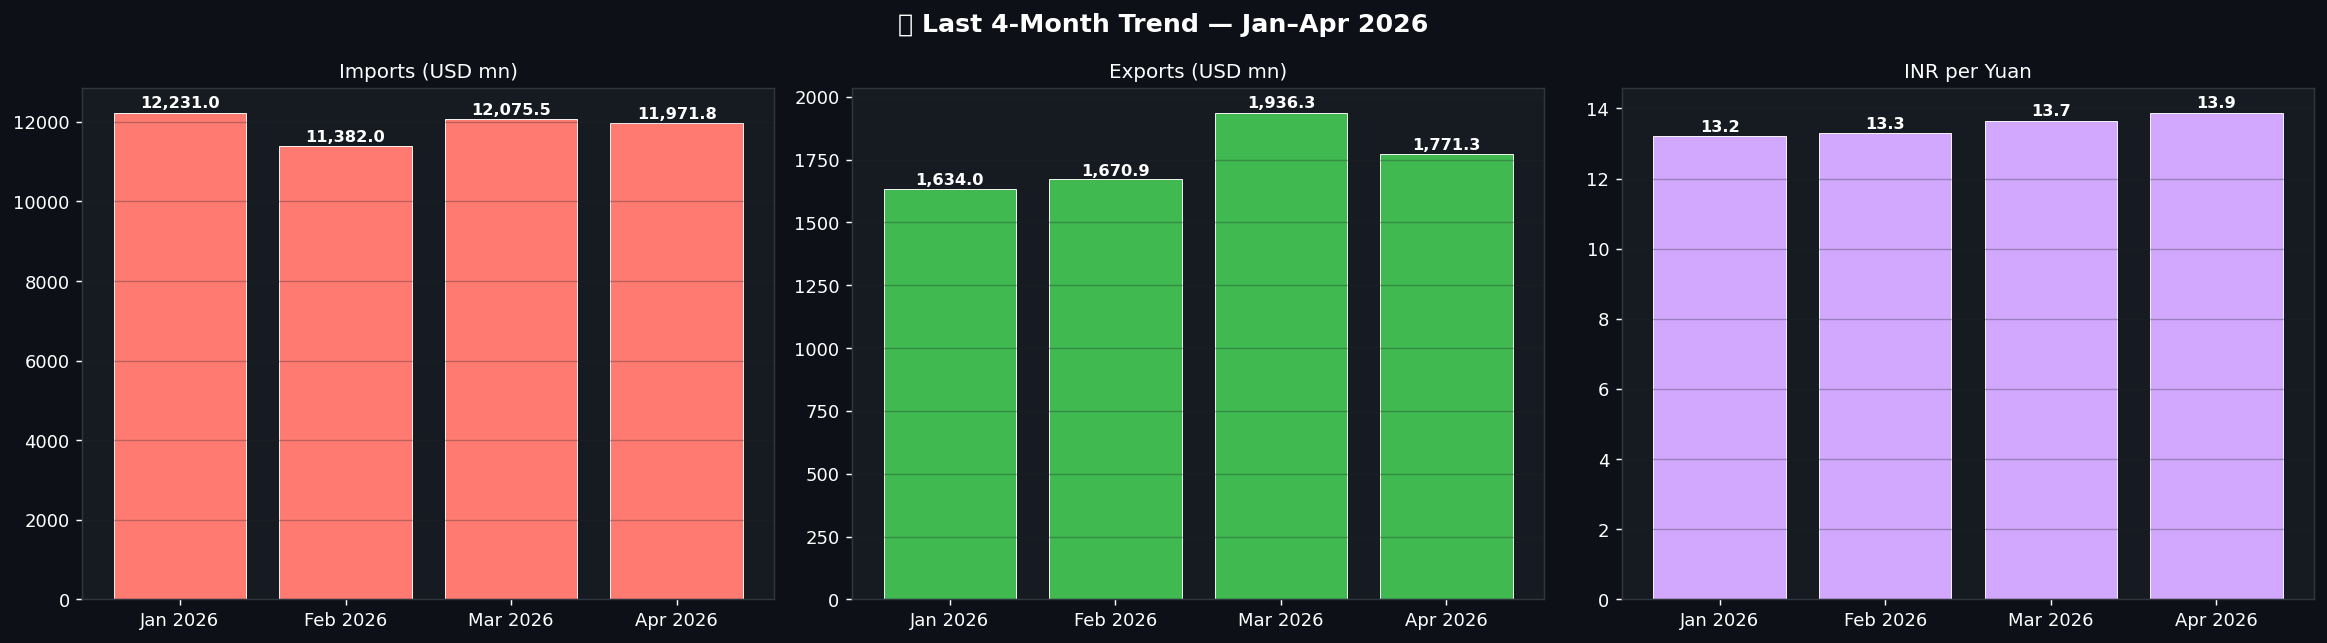


=== Last 4 Months (Jan–Apr 2026) ===


,Imports,Exports,Trade_Deficit,Exchange_Rate,INR_Depreciation
Month,,,,,
2026-01-01 00:00:00,12231.000000,1633.980000,10597.020000,13.210000,2.961808
2026-02-01 00:00:00,11382.010000,1670.930000,9711.080000,13.300000,0.681302
2026-03-01 00:00:00,12075.480000,1936.340000,10139.140000,13.650000,2.631579
2026-04-01 00:00:00,11971.780000,1771.320000,10200.460000,13.880000,1.684982



📌 Recent trend: INR/CNY has climbed sharply to 13.88 by April 2026, yet imports continue rising —
   indicating that currency depreciation is failing to compress import demand from China.


In [107]:

last4 = df.tail(4).copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')
plt.suptitle('📅 Last 4-Month Trend — Jan–Apr 2026', color='white', fontsize=14, fontweight='bold')

for ax, (col, clr, lbl) in zip(axes, [
    ('Imports','#ff7b72','Imports (USD mn)'),
    ('Exports','#3fb950','Exports (USD mn)'),
    ('Exchange_Rate','#d2a8ff','INR per Yuan'),
]):
    ax.bar(last4['Month'].dt.strftime('%b %Y'), last4[col], color=clr, edgecolor='white', lw=0.5)
    for i, (m, v) in enumerate(zip(last4['Month'], last4[col])):
        ax.text(i, v + v*0.01, f'{v:,.1f}', ha='center', color='white', fontsize=9, fontweight='bold')
    ax.set_title(lbl, color='white', fontsize=11)
    ax.tick_params(colors='white')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('last4months.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n=== Last 4 Months (Jan–Apr 2026) ===")
display(last4[['Month','Imports','Exports','Trade_Deficit','Exchange_Rate','INR_Depreciation']].set_index('Month').style.background_gradient(cmap='RdYlGn_r'))
print("\n📌 Recent trend: INR/CNY has climbed sharply to 13.88 by April 2026, yet imports continue rising —")
print("   indicating that currency depreciation is failing to compress import demand from China.")


---
## 📐 PART 6 — Statistical Analysis

### A. Correlation by Period


In [108]:

periods_map = {
    'Corona (2021)':        df[df['Period']=='Corona (2021)'],
    'Post-Corona (2022-25)': df[df['Period']=='Post-Corona (2022-25)'],
    'Full Period':           df,
}

print("=" * 70)
print(f"{'Period':<25} {'Variable':<20} {'Pearson r':>10} {'p-value':>10} {'Spearman r':>12}")
print("=" * 70)

for period_name, subset in periods_map.items():
    s = subset[['Exchange_Rate','Imports','Exports','Trade_Deficit','Net_Exports']].dropna()
    for col in ['Imports','Exports','Trade_Deficit','Net_Exports']:
        pr, pp = pearsonr(s['Exchange_Rate'], s[col])
        sr, sp = spearmanr(s['Exchange_Rate'], s[col])
        print(f"{period_name:<25} {col:<20} {pr:>+10.3f} {pp:>10.4f} {sr:>+12.3f}")
    print("-" * 70)


Period                    Variable              Pearson r    p-value   Spearman r
Corona (2021)             Imports                  +0.802     0.0017       +0.757
Corona (2021)             Exports                  -0.479     0.1152       -0.354
Corona (2021)             Trade_Deficit            +0.812     0.0013       +0.690
Corona (2021)             Net_Exports              -0.812     0.0013       -0.690
----------------------------------------------------------------------
Post-Corona (2022-25)     Imports                  +0.589     0.0000       +0.457
Post-Corona (2022-25)     Exports                  +0.509     0.0002       +0.289
Post-Corona (2022-25)     Trade_Deficit            +0.479     0.0006       +0.397
Post-Corona (2022-25)     Net_Exports              -0.479     0.0006       -0.397
----------------------------------------------------------------------
Full Period               Imports                  +0.756     0.0000       +0.669
Full Period               Exports     

### B. Regression Analysis

In [109]:

print("\n" + "="*60)
print("REGRESSION: Trade Deficit ~ Exchange Rate")
print("="*60)
d = df[['Exchange_Rate','Trade_Deficit','Imports','Exports',
        'Net_Exports','Total_Trade']].dropna()
X = sm.add_constant(d['Exchange_Rate'])

for dep in ['Trade_Deficit','Imports','Exports','Net_Exports','Total_Trade']:
    model = sm.OLS(d[dep], X).fit()
    print(f"\nDependent: {dep}")
    print(f"  Intercept: {model.params['const']:+,.2f}  "
          f"Coef(FX): {model.params['Exchange_Rate']:+,.2f}  "
          f"R²: {model.rsquared:.3f}  p: {model.pvalues['Exchange_Rate']:.4f}")

# Multiple regression: Imports ~ Exchange_Rate + time trend
d2 = df.copy().dropna(subset=['Exchange_Rate','Imports'])
d2['t'] = range(len(d2))
X2 = sm.add_constant(d2[['Exchange_Rate','t']])
m2 = sm.OLS(d2['Imports'], X2).fit()
print("\n" + "="*60)
print("MULTIPLE REGRESSION: Imports ~ Exchange_Rate + Time Trend")
print("="*60)
print(m2.summary().tables[1])



REGRESSION: Trade Deficit ~ Exchange Rate

Dependent: Trade_Deficit
  Intercept: -15,815.27  Coef(FX): +1,965.90  R²: 0.450  p: 0.0000

Dependent: Imports
  Intercept: -15,587.27  Coef(FX): +2,071.57  R²: 0.572  p: 0.0000

Dependent: Exports
  Intercept: +228.00  Coef(FX): +105.67  R²: 0.026  p: 0.2053

Dependent: Net_Exports
  Intercept: +15,815.27  Coef(FX): -1,965.90  R²: 0.450  p: 0.0000

Dependent: Total_Trade
  Intercept: -15,359.28  Coef(FX): +2,177.25  R²: 0.649  p: 0.0000

MULTIPLE REGRESSION: Imports ~ Exchange_Rate + Time Trend
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -4787.1346   2655.698     -1.803      0.076   -1.01e+04     523.262
Exchange_Rate  1037.8807    236.139      4.395      0.000     565.691    1510.070
t                45.5632      6.948      6.557      0.000      31.669      59.457


### C. ADF Stationarity Tests

In [110]:

print("=== Augmented Dickey-Fuller Stationarity Tests ===\n")
print(f"{'Variable':<22} {'ADF Stat':>10} {'p-value':>10} {'Stationary?':>12}")
print("-" * 58)
for col in ['Exchange_Rate','Imports','Exports','Trade_Deficit','Net_Exports','Total_Trade']:
    s = df[col].dropna()
    res = adfuller(s, autolag='AIC')
    stationary = "✅ Yes" if res[1] < 0.05 else "❌ No (unit root)"
    print(f"{col:<22} {res[0]:>10.3f} {res[1]:>10.4f} {stationary:>12}")
print("\n📌 Non-stationary series (unit root) indicate long-term trending behaviour.")
print("   First-differencing or cointegration analysis would be appropriate for modelling.")


=== Augmented Dickey-Fuller Stationarity Tests ===

Variable                 ADF Stat    p-value  Stationary?
----------------------------------------------------------
Exchange_Rate               2.160     0.9988 ❌ No (unit root)
Imports                    -1.993     0.2896 ❌ No (unit root)
Exports                    -2.545     0.1050 ❌ No (unit root)
Trade_Deficit              -2.079     0.2532 ❌ No (unit root)
Net_Exports                -2.079     0.2532 ❌ No (unit root)
Total_Trade                -1.181     0.6818 ❌ No (unit root)

📌 Non-stationary series (unit root) indicate long-term trending behaviour.
   First-differencing or cointegration analysis would be appropriate for modelling.


### D. Hypothesis Tests

In [111]:

print("=== Hypothesis Tests: Does INR Depreciation Significantly Predict Trade Outcomes? ===\n")

# Classify months by depreciation (above/below median)
dep_med = df['INR_Depreciation'].median()
high_dep = df[df['INR_Depreciation'] > dep_med]
low_dep  = df[df['INR_Depreciation'] <= dep_med]

for col in ['Imports','Exports','Trade_Deficit','Net_Exports']:
    t, p = ttest_ind(high_dep[col].dropna(), low_dep[col].dropna())
    sig = "✅ Significant" if p < 0.05 else "❌ Not significant"
    print(f"{col:<22} t={t:+.3f}  p={p:.4f}  → {sig}")

print("\n📌 Interpretation: If imports/trade deficit are significantly higher in high-depreciation months,")
print("   it confirms that currency weakness correlates with worsening trade outcomes (not improvement).")


=== Hypothesis Tests: Does INR Depreciation Significantly Predict Trade Outcomes? ===

Imports                t=+2.943  p=0.0046  → ✅ Significant
Exports                t=+0.521  p=0.6045  → ❌ Not significant
Trade_Deficit          t=+2.585  p=0.0122  → ✅ Significant
Net_Exports            t=-2.585  p=0.0122  → ✅ Significant

📌 Interpretation: If imports/trade deficit are significantly higher in high-depreciation months,
   it confirms that currency weakness correlates with worsening trade outcomes (not improvement).


### E. Seasonal Decomposition

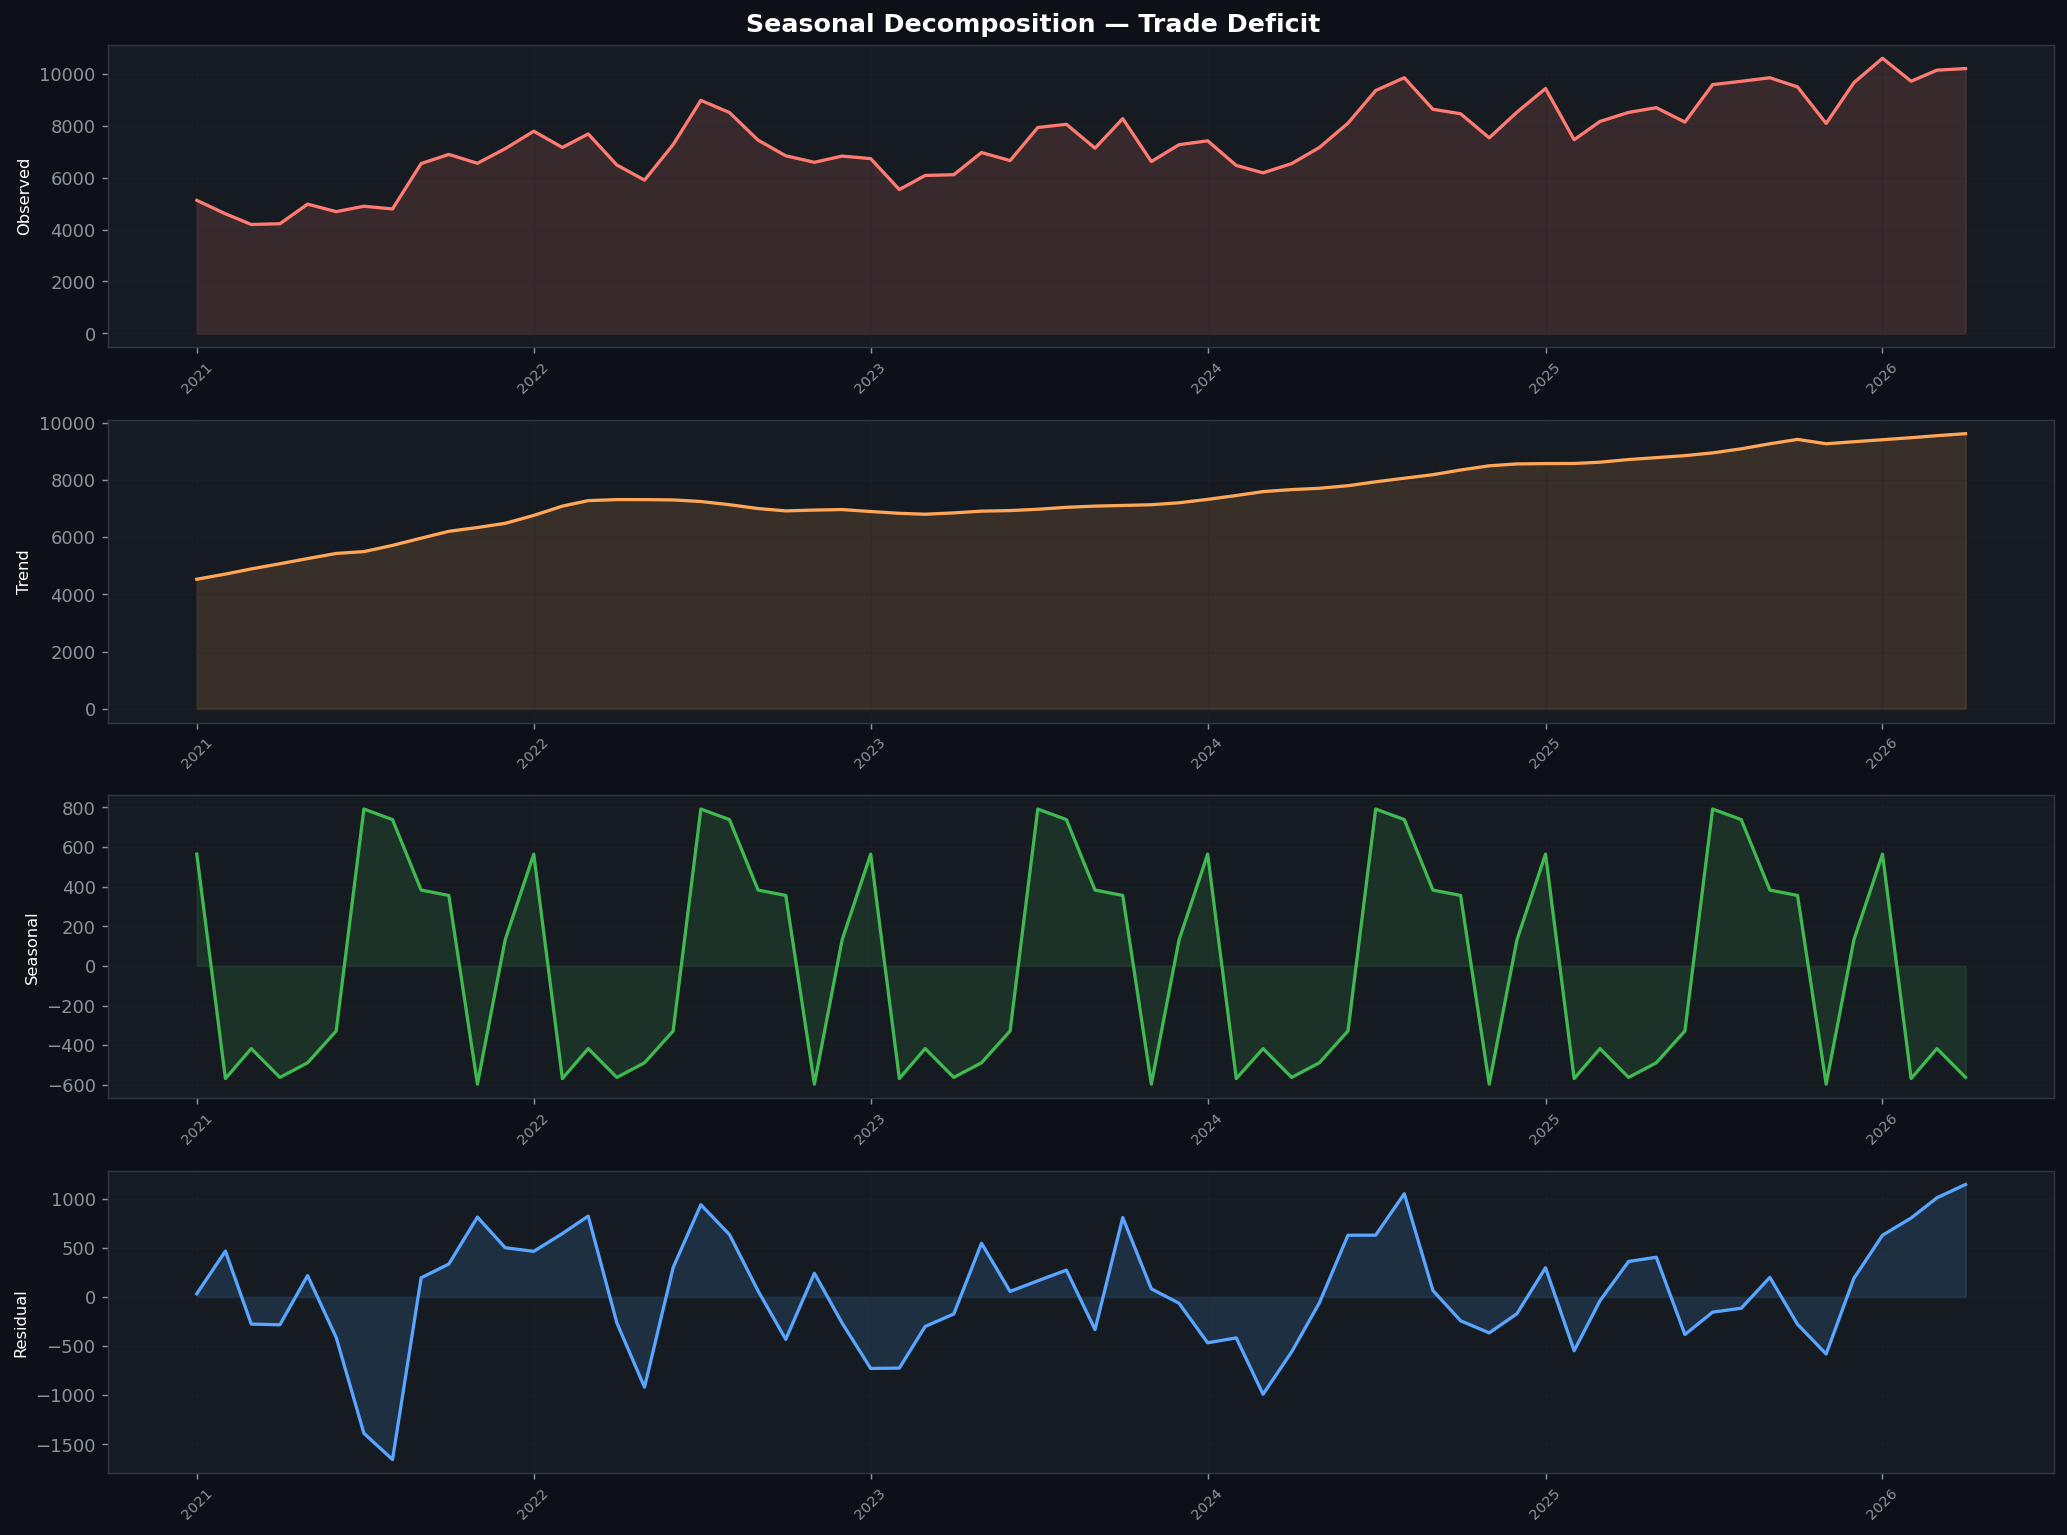

In [112]:

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.patch.set_facecolor('#0d1117')
plt.suptitle('Seasonal Decomposition — Trade Deficit', color='white', fontsize=14, fontweight='bold')

ts = df.set_index('Month')['Trade_Deficit'].dropna()
result = seasonal_decompose(ts, model='additive', period=12, extrapolate_trend='freq')

components = [
    (result.observed,  '#ff7b72', 'Observed'),
    (result.trend,     '#ffa657', 'Trend'),
    (result.seasonal,  '#3fb950', 'Seasonal'),
    (result.resid,     '#58a6ff', 'Residual'),
]

for ax, (comp, clr, lbl) in zip(axes, components):
    ax.plot(comp.index, comp.values, color=clr, lw=1.8)
    ax.fill_between(comp.index, comp.values, alpha=0.15, color=clr)
    ax.set_ylabel(lbl, color='white', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.savefig('decomposition.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


### F. Lag Correlation Analysis

Examines whether **today's INR depreciation predicts trade outcomes in future months** (or vice versa).  
A lag of +k means: "Exchange Rate at time t correlates with trade variable at time t+k."  
This reveals the **delayed transmission effect** of currency movements on trade flows.

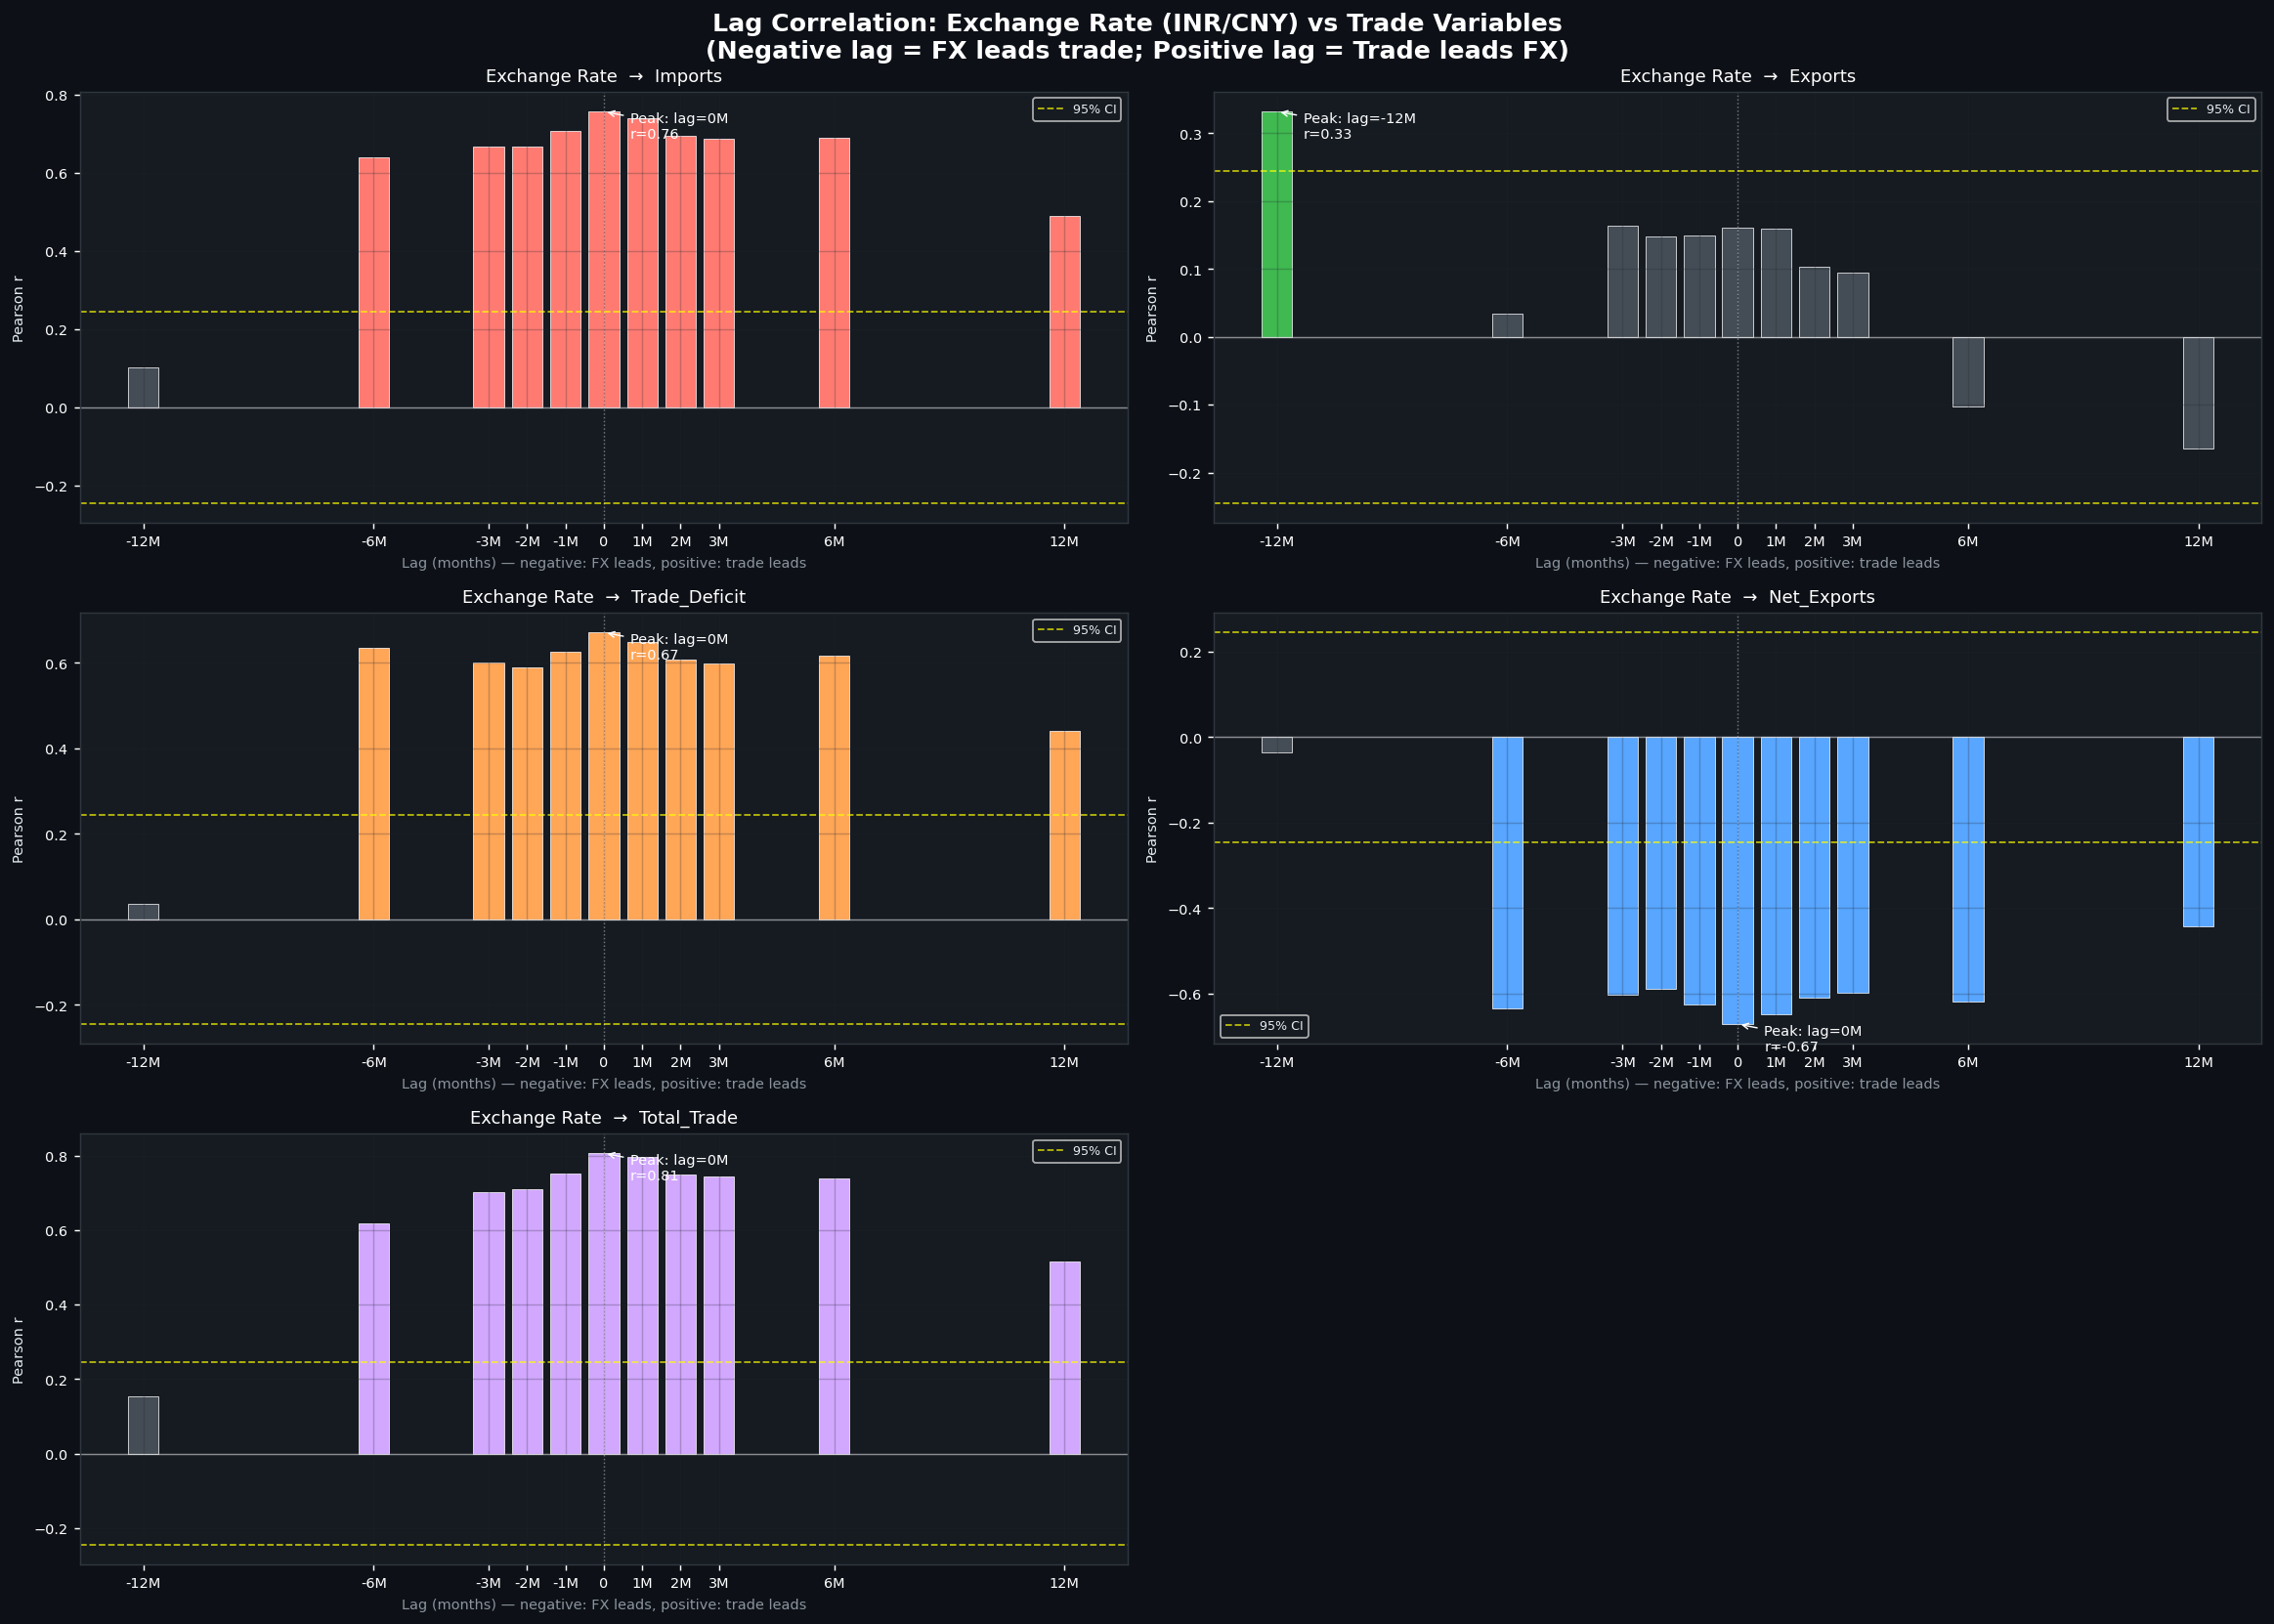


=== Lag Correlation Summary (Peak Custom Lag per Variable) ===

Variable               Best Lag        r    p-value Direction
-----------------------------------------------------------------
Imports                      0M   +0.756     0.0000  Contemporaneous
Exports                    -12M   +0.332     0.0162  FX leads trade
Trade_Deficit                0M   +0.671     0.0000  Contemporaneous
Net_Exports                  0M   -0.671     0.0000  Contemporaneous
Total_Trade                  0M   +0.806     0.0000  Contemporaneous

📌 Colored bars = statistically significant (p < 0.05). Grey bars = not significant.
📌 Negative lag: Exchange Rate movement at time t correlates with trade at t+|lag|.
📌 This reveals the transmission delay of currency shocks into trade flows.


In [132]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# ── Variables to test against Exchange Rate ──
target_vars = {
    'Imports':          '#ff7b72',
    'Exports':          '#3fb950',
    'Trade_Deficit':    '#ffa657',
    'Net_Exports':      '#58a6ff',
    'Total_Trade':      '#d2a8ff',
}

# FIXED: Explicitly defining custom lag points: ±1, ±3, ±6, ±12 and 0
lags = [-12, -6, -3, -2,  -1, 0, 1, 2 , 3, 6, 12]

# ── Compute lag correlations ──
lag_results = {}
for col, clr in target_vars.items():
    corrs, pvals = [], []
    for lag in lags:
        fx_shifted = df['Exchange_Rate'].shift(-lag)   # shift FX forward by lag
        combined   = pd.concat([fx_shifted, df[col]], axis=1).dropna()
        r, p = pearsonr(combined.iloc[:, 0], combined.iloc[:, 1])
        corrs.append(r)
        pvals.append(p)
    lag_results[col] = {'corr': corrs, 'pval': pvals, 'color': clr}

# ── Plot ──
fig, axes = plt.subplots(3, 2, figsize=(18, 13))
fig.patch.set_facecolor('#0d1117')
plt.suptitle('Lag Correlation: Exchange Rate (INR/CNY) vs Trade Variables\n'
             '(Negative lag = FX leads trade; Positive lag = Trade leads FX)',
             color='white', fontsize=14, fontweight='bold')

axes_flat = axes.flatten()

for i, (col, res) in enumerate(lag_results.items()):
    ax  = axes_flat[i]
    clr = res['color']
    corrs = res['corr']
    pvals = res['pval']

    # Plot custom discrete lags as a bar chart
    bars = ax.bar(lags, corrs,
                  color=[clr if p < 0.05 else '#444d56' for p in pvals],
                  edgecolor='white', linewidth=0.4, width=0.8)

    # Significance threshold lines (95%)
    n = len(df)
    sig_bound = 1.96 / np.sqrt(n)
    ax.axhline( sig_bound, color='yellow', lw=1, ls='--', alpha=0.7, label='95% CI')
    ax.axhline(-sig_bound, color='yellow', lw=1, ls='--', alpha=0.7)
    ax.axhline(0, color='white', lw=0.8, alpha=0.5)
    ax.axvline(0, color='white', lw=0.8, ls=':', alpha=0.4)

    # Annotate the peak lag among the specified list
    peak_idx = int(np.argmax(np.abs(corrs)))
    ax.annotate(f'Peak: lag={lags[peak_idx]}M\nr={corrs[peak_idx]:.2f}',
                xy=(lags[peak_idx], corrs[peak_idx]),
                xytext=(15, -15), textcoords='offset points',
                color='white', fontsize=8,
                arrowprops=dict(arrowstyle='->', color='white', lw=0.8))

    ax.set_title(f'Exchange Rate  →  {col}', color='white', fontsize=10, pad=6)
    ax.set_xlabel('Lag (months) — negative: FX leads, positive: trade leads',
                  fontsize=8, color='#8b949e')
    ax.set_ylabel('Pearson r', fontsize=8)
    
    # FIXED: Setting specific x-ticks to correspond exactly with your custom list
    ax.set_xticks(lags)
    ax.set_xticklabels([f'{l}M' if l != 0 else '0' for l in lags])
    
    ax.tick_params(colors='white', labelsize=8)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7)

# Hide unused subplot
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig('lag_correlation_custom.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ── Summary table ──
print("\n=== Lag Correlation Summary (Peak Custom Lag per Variable) ===\n")
print(f"{'Variable':<20} {'Best Lag':>10} {'r':>8} {'p-value':>10} {'Direction'}")
print("-" * 65)
for col, res in lag_results.items():
    corrs, pvals = res['corr'], res['pval']
    peak_idx = int(np.argmax(np.abs(corrs)))
    best_lag = lags[peak_idx]
    direction = ("FX leads trade" if best_lag < 0
                 else "Trade leads FX" if best_lag > 0
                 else "Contemporaneous")
    print(f"{col:<20} {best_lag:>9}M  {corrs[peak_idx]:>+7.3f}  {pvals[peak_idx]:>9.4f}  {direction}")

print("\n📌 Colored bars = statistically significant (p < 0.05). Grey bars = not significant.")
print("📌 Negative lag: Exchange Rate movement at time t correlates with trade at t+|lag|.")
print("📌 This reveals the transmission delay of currency shocks into trade flows.")

### G. Lag Regression Analysis

Regresses each trade variable on **lagged Exchange Rate values** to quantify how much of the trade movement  
can be explained by currency changes from 1–6 months earlier.  
Reports R², coefficients, and p-values for each lag depth.

=== Lag Regression Results: Trade Variable ~ Lagged Exchange Rate ===



,Variable,Lag,Intercept,Coefficient,R2,Adj_R2,p_value,Significant
0,Imports,1,"-16,475.9","+2,155.57",0.498,0.490,0.0000,True
1,Imports,2,"-17,695.3","+2,268.22",0.445,0.435,0.0000,True
2,Imports,3,"-20,450.6","+2,510.57",0.446,0.437,0.0000,True
3,Imports,6,"-27,529.5","+3,138.36",0.409,0.398,0.0000,True
4,Imports,8,"-21,832.4","+2,664.65",0.241,0.227,0.0001,True
5,Imports,12,"2,103.5",+619.43,0.010,-0.010,0.4759,False
6,Imports,24,"3,430.4",+526.58,0.007,-0.019,0.6157,False
7,Exports,1,163.1,+111.35,0.022,0.006,0.2439,False
8,Exports,2,-16.4,+126.55,0.022,0.006,0.2494,False
9,Exports,3,-232.1,+143.54,0.027,0.011,0.2052,False


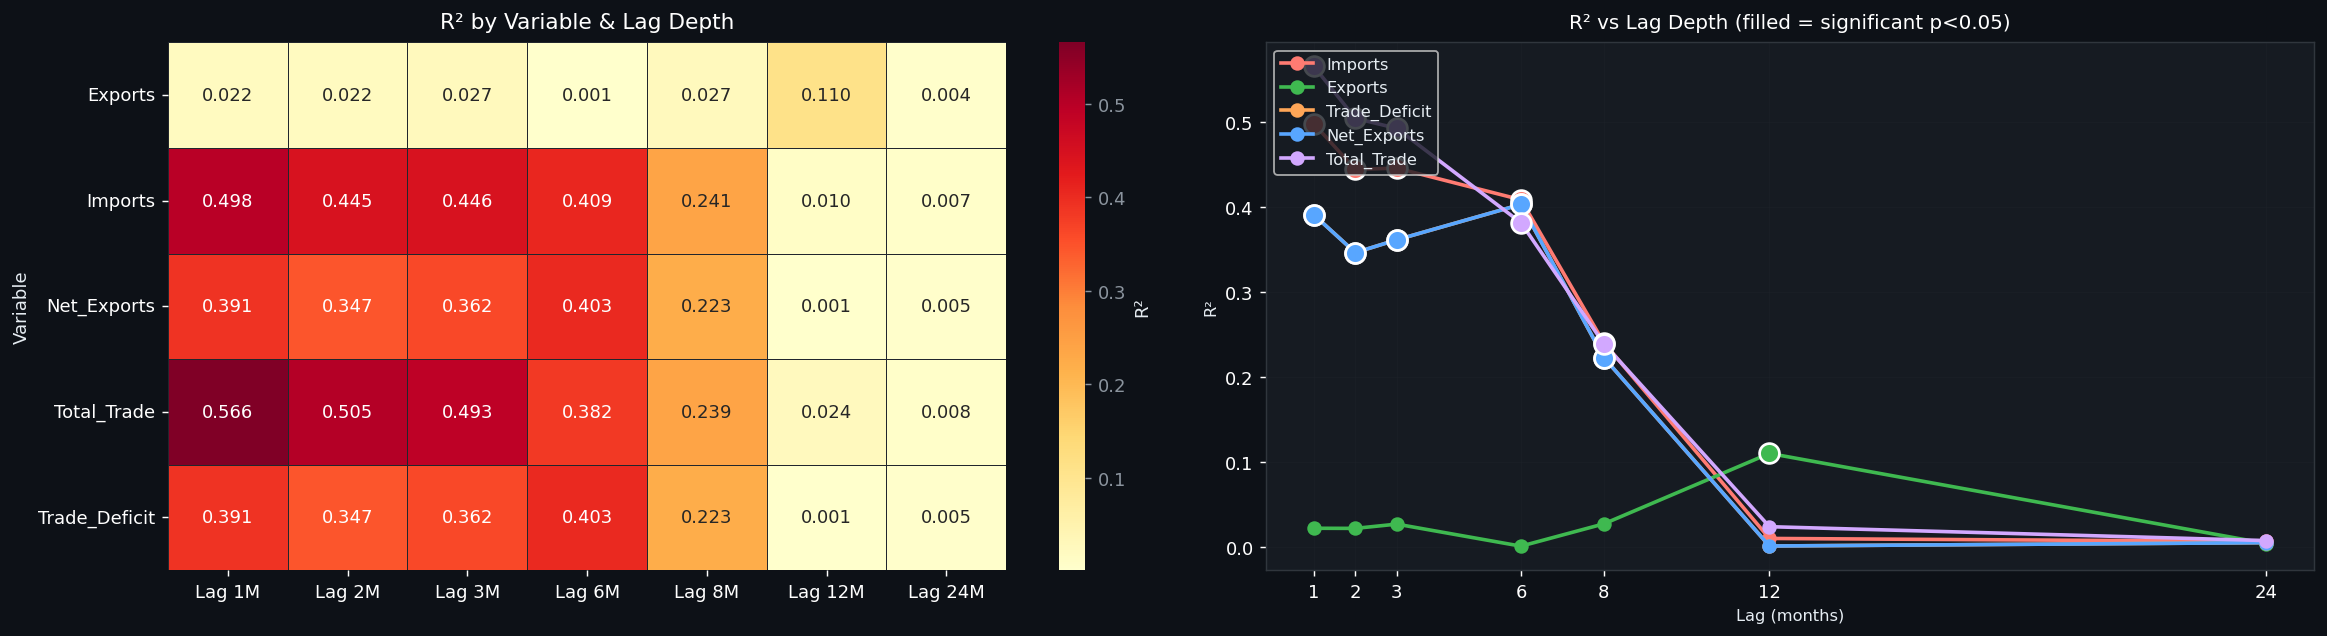


=== Best Lag (Highest R²) per Variable ===

Variable               Best Lag       R²       Coef    p-value Sig?
----------------------------------------------------------------------
Exports                    12M    0.110    +407.61     0.0162  ✅
Imports                     1M    0.498   +2155.57     0.0000  ✅
Net_Exports                 6M    0.403   -3104.12     0.0000  ✅
Total_Trade                 1M    0.566   +2266.93     0.0000  ✅
Trade_Deficit               6M    0.403   +3104.12     0.0000  ✅

📌 Interpretation:
   A positive coefficient means: higher INR/CNY at lag k → higher value of trade variable k months later.
   Rising R² at longer lags suggests delayed transmission of currency shocks into trade.
   Non-significant results (p > 0.05) indicate no reliable predictive relationship at that lag depth.


In [129]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

reg_targets = ['Imports', 'Exports', 'Trade_Deficit', 'Net_Exports', 'Total_Trade']
lag_depths  = [1, 2, 3, 6, 8, 12, 24]   # months to test

# ── Collect results ──
records = []
for col in reg_targets:
    for lag in lag_depths:
        temp = df[['Exchange_Rate', col]].copy()
        temp['FX_lagged'] = temp['Exchange_Rate'].shift(lag)
        temp = temp.dropna()

        X = sm.add_constant(temp['FX_lagged'])
        y = temp[col]
        model = sm.OLS(y, X).fit()

        records.append({
            'Variable':    col,
            'Lag':         lag,
            'Intercept':   model.params['const'],
            'Coefficient': model.params['FX_lagged'],
            'R2':          model.rsquared,
            'Adj_R2':      model.rsquared_adj,
            'p_value':     model.pvalues['FX_lagged'],
            'Significant': model.pvalues['FX_lagged'] < 0.05,
        })

lag_reg_df = pd.DataFrame(records)

# ── Display results table ──
print("=== Lag Regression Results: Trade Variable ~ Lagged Exchange Rate ===\n")
display(lag_reg_df.style
    .background_gradient(subset=['R2'], cmap='YlGn')
    .background_gradient(subset=['p_value'], cmap='RdYlGn_r')
    # FIXED: Replaced .applymap with .map for pandas 2.1+ compatibility
    .map(lambda v: 'color: #3fb950; font-weight:bold' if v else 'color: #8b949e',
         subset=['Significant'])
    .format({'Intercept':'{:,.1f}','Coefficient':'{:+,.2f}',
             'R2':'{:.3f}','Adj_R2':'{:.3f}','p_value':'{:.4f}'})
)

# ── R² Heatmap across lags ──
pivot_r2 = lag_reg_df.pivot(index='Variable', columns='Lag', values='R2')
pivot_r2.columns = [f'Lag {c}M' for c in pivot_r2.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')

sns.heatmap(pivot_r2, ax=axes[0], annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, linecolor='#21262d', cbar_kws={'label': 'R²'})
axes[0].set_title('R² by Variable & Lag Depth', color='white', fontsize=12, pad=8)
axes[0].tick_params(colors='white')

# ── Coefficient plot per variable ──
colors_reg = ['#ff7b72','#3fb950','#ffa657','#58a6ff','#d2a8ff']
for col, clr in zip(reg_targets, colors_reg):
    sub = lag_reg_df[lag_reg_df['Variable'] == col]
    axes[1].plot(sub['Lag'], sub['R2'], marker='o', lw=2, color=clr,
                 label=col, markersize=7)
    # Mark significant points
    sig = sub[sub['Significant']]
    axes[1].scatter(sig['Lag'], sig['R2'], s=120, color=clr,
                    edgecolors='white', lw=1.5, zorder=5)

axes[1].set_title('R² vs Lag Depth (filled = significant p<0.05)',
                  color='white', fontsize=11, pad=8)
axes[1].set_xlabel('Lag (months)', fontsize=9)
axes[1].set_ylabel('R²', fontsize=9)
axes[1].legend(fontsize=9, loc='upper left')
axes[1].tick_params(colors='white')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(lag_depths)

plt.tight_layout()
plt.savefig('lag_regression.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ── Best lag per variable ──
print("\n=== Best Lag (Highest R²) per Variable ===\n")
best = lag_reg_df.loc[lag_reg_df.groupby('Variable')['R2'].idxmax()]
print(f"{'Variable':<20} {'Best Lag':>10} {'R²':>8} {'Coef':>10} {'p-value':>10} {'Sig?'}")
print("-" * 70)
for _, row in best.iterrows():
    sig = "✅" if row['Significant'] else "❌"
    print(f"{row['Variable']:<20} {int(row['Lag']):>8}M  "
          f"{row['R2']:>7.3f}  {row['Coefficient']:>+9.2f}  "
          f"{row['p_value']:>9.4f}  {sig}")

print("\n📌 Interpretation:")
print("   A positive coefficient means: higher INR/CNY at lag k → higher value of trade variable k months later.")
print("   Rising R² at longer lags suggests delayed transmission of currency shocks into trade.")
print("   Non-significant results (p > 0.05) indicate no reliable predictive relationship at that lag depth.")

---
## 🎨 PART 7 — Advanced Visualizations


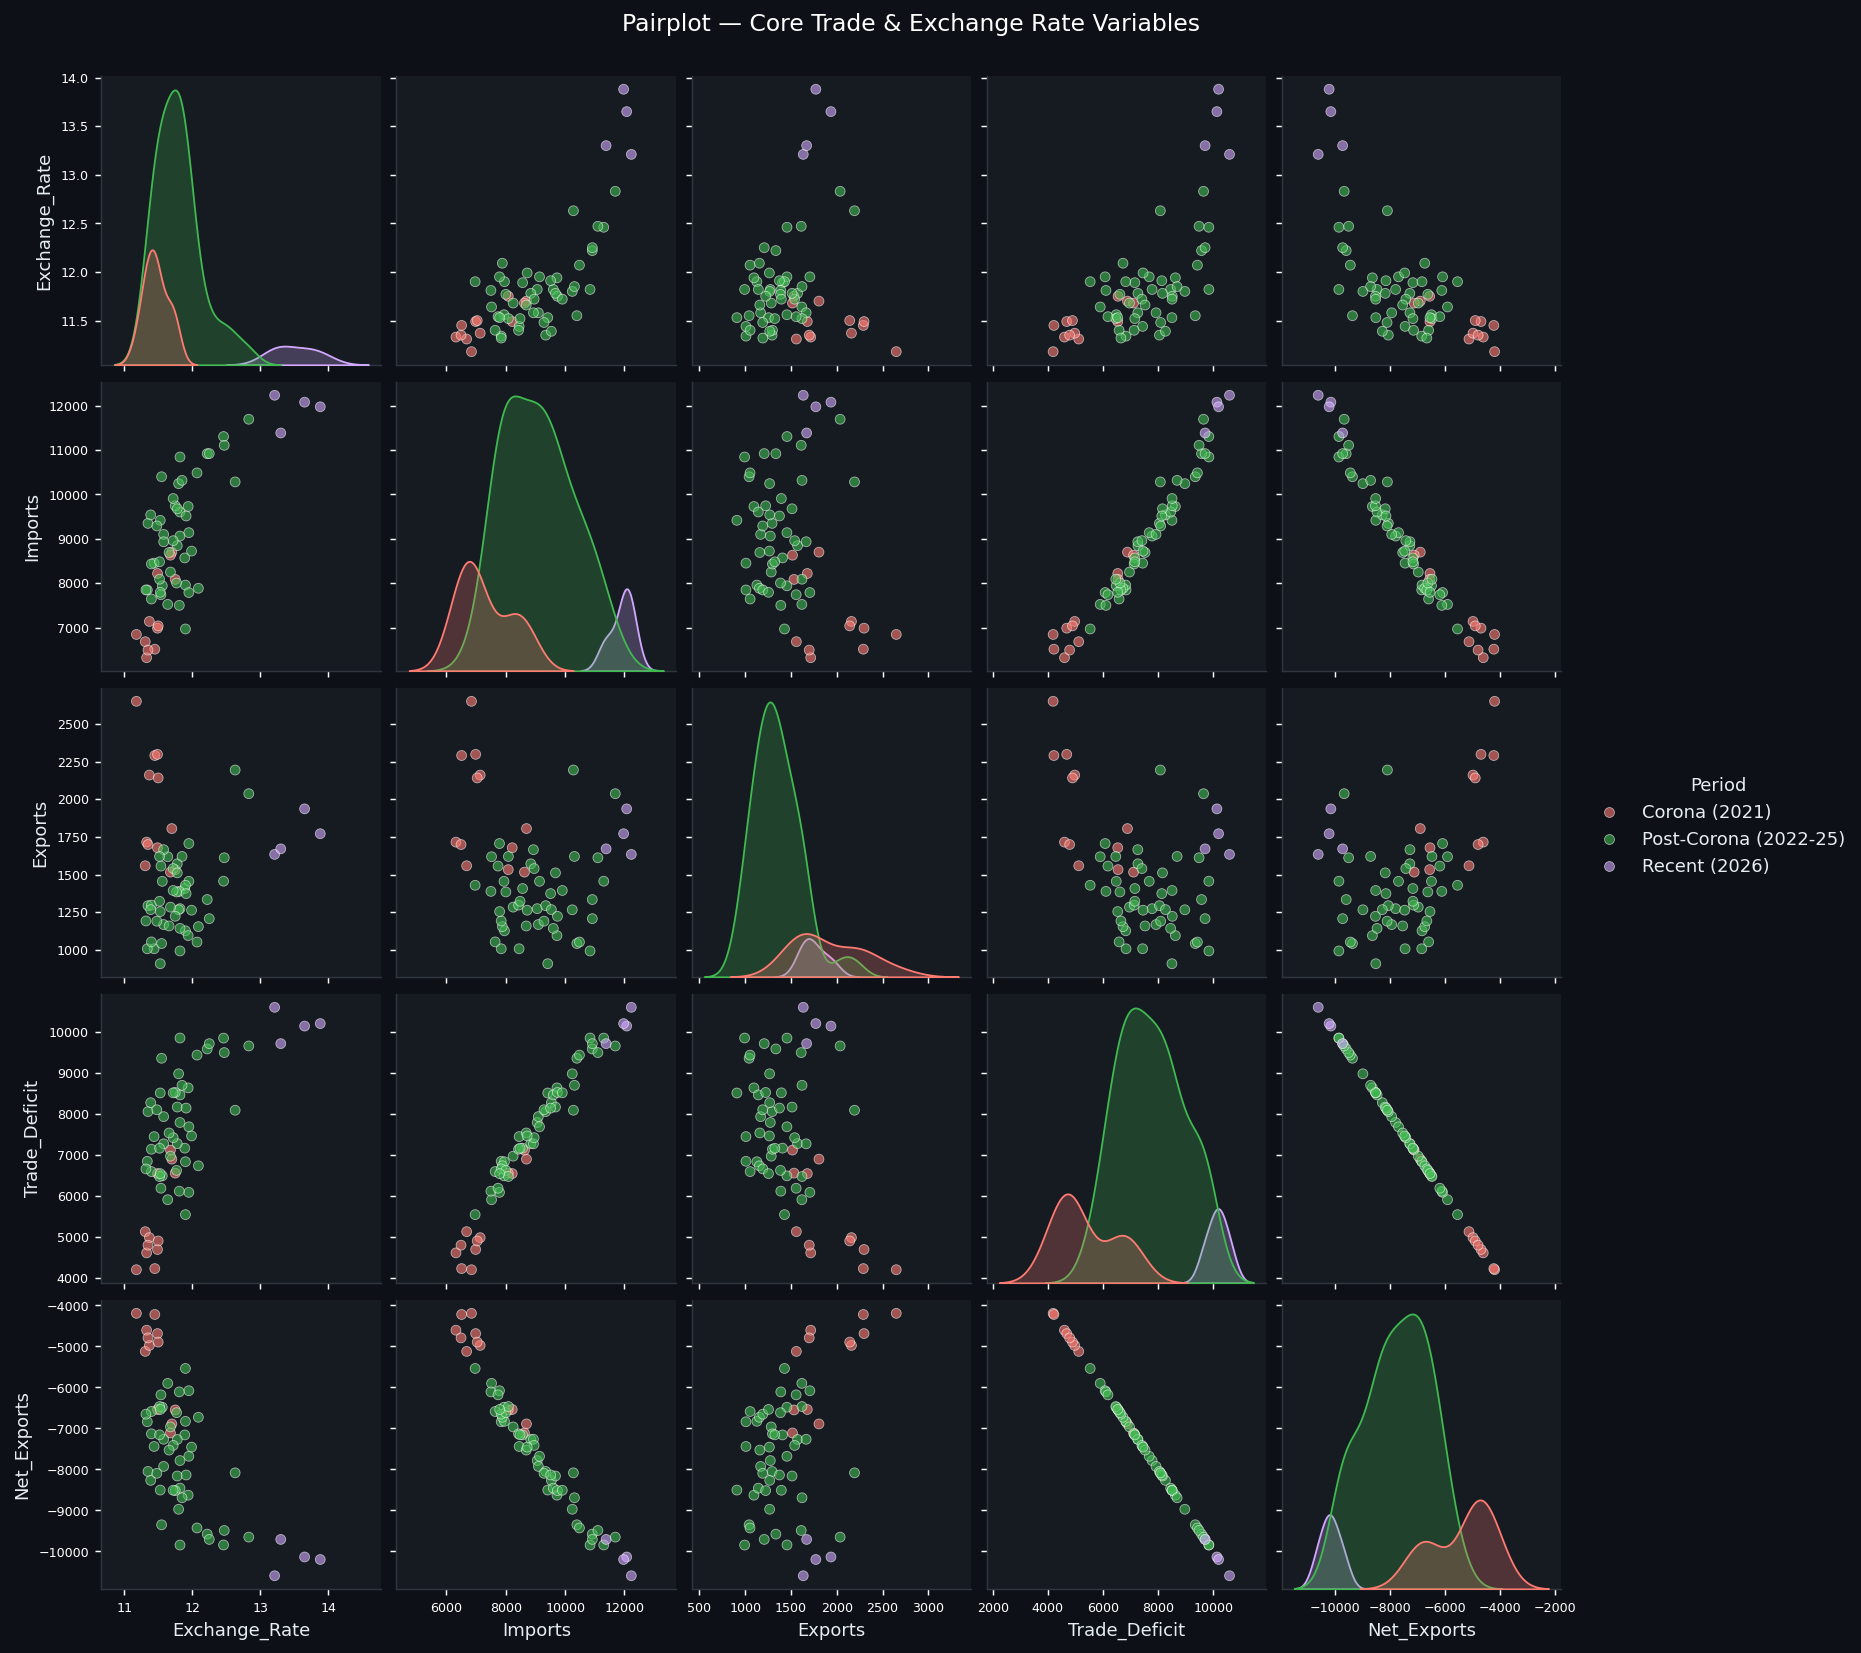

In [113]:

# ── Pairplot ──
pair_cols = ['Exchange_Rate','Imports','Exports','Trade_Deficit','Net_Exports']
pair_df = df[pair_cols + ['Period']].dropna()

g = sns.pairplot(pair_df, hue='Period', diag_kind='kde',
                 plot_kws={'alpha':0.6, 's':30},
                 palette={'Corona (2021)':'#ff7b72',
                          'Post-Corona (2022-25)':'#3fb950',
                          'Recent (2026)':'#d2a8ff'})
g.fig.patch.set_facecolor('#0d1117')
g.fig.suptitle('Pairplot — Core Trade & Exchange Rate Variables', color='white', y=1.02, fontsize=13)
for ax in g.axes.flatten():
    if ax:
        ax.set_facecolor('#161b22')
        ax.tick_params(colors='white', labelsize=7)
plt.savefig('pairplot.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


In [114]:

# ── Bubble chart: Exchange Rate vs Trade Deficit, bubble = Imports ──
fig = px.scatter(
    df.dropna(), x='Exchange_Rate', y='Trade_Deficit', size='Imports',
    color='INR_Depreciation', color_continuous_scale='RdYlGn_r',
    hover_data=['Month','Imports','Exports'],
    title='🔵 Bubble Chart: Exchange Rate vs Trade Deficit (bubble = Import Volume)',
    labels={'Exchange_Rate':'INR per Yuan','Trade_Deficit':'Trade Deficit (USD mn)'},
    template='plotly_dark', size_max=35
)
fig.update_layout(plot_bgcolor='#161b22', paper_bgcolor='#0d1117')
fig.show()


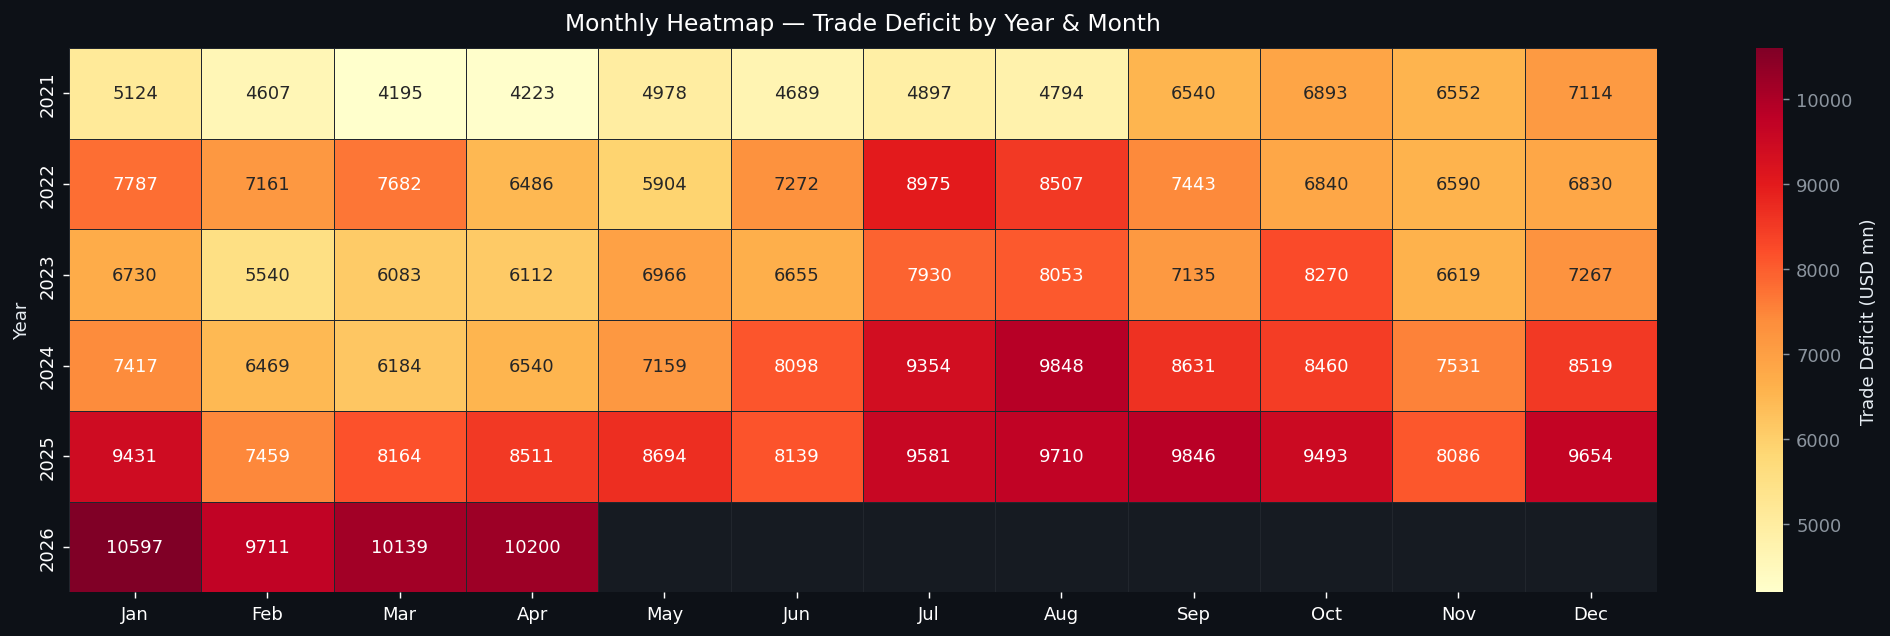

In [115]:

# ── Monthly Heatmap ──
df['Year'] = df['Month'].dt.year
df['Mon']  = df['Month'].dt.month

pivot = df.pivot_table(index='Year', columns='Mon', values='Trade_Deficit', aggfunc='mean')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, linecolor='#21262d',
            cbar_kws={'label':'Trade Deficit (USD mn)'})
ax.set_title('Monthly Heatmap — Trade Deficit by Year & Month',
             color='white', fontsize=13, pad=10)
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig('monthly_heatmap.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


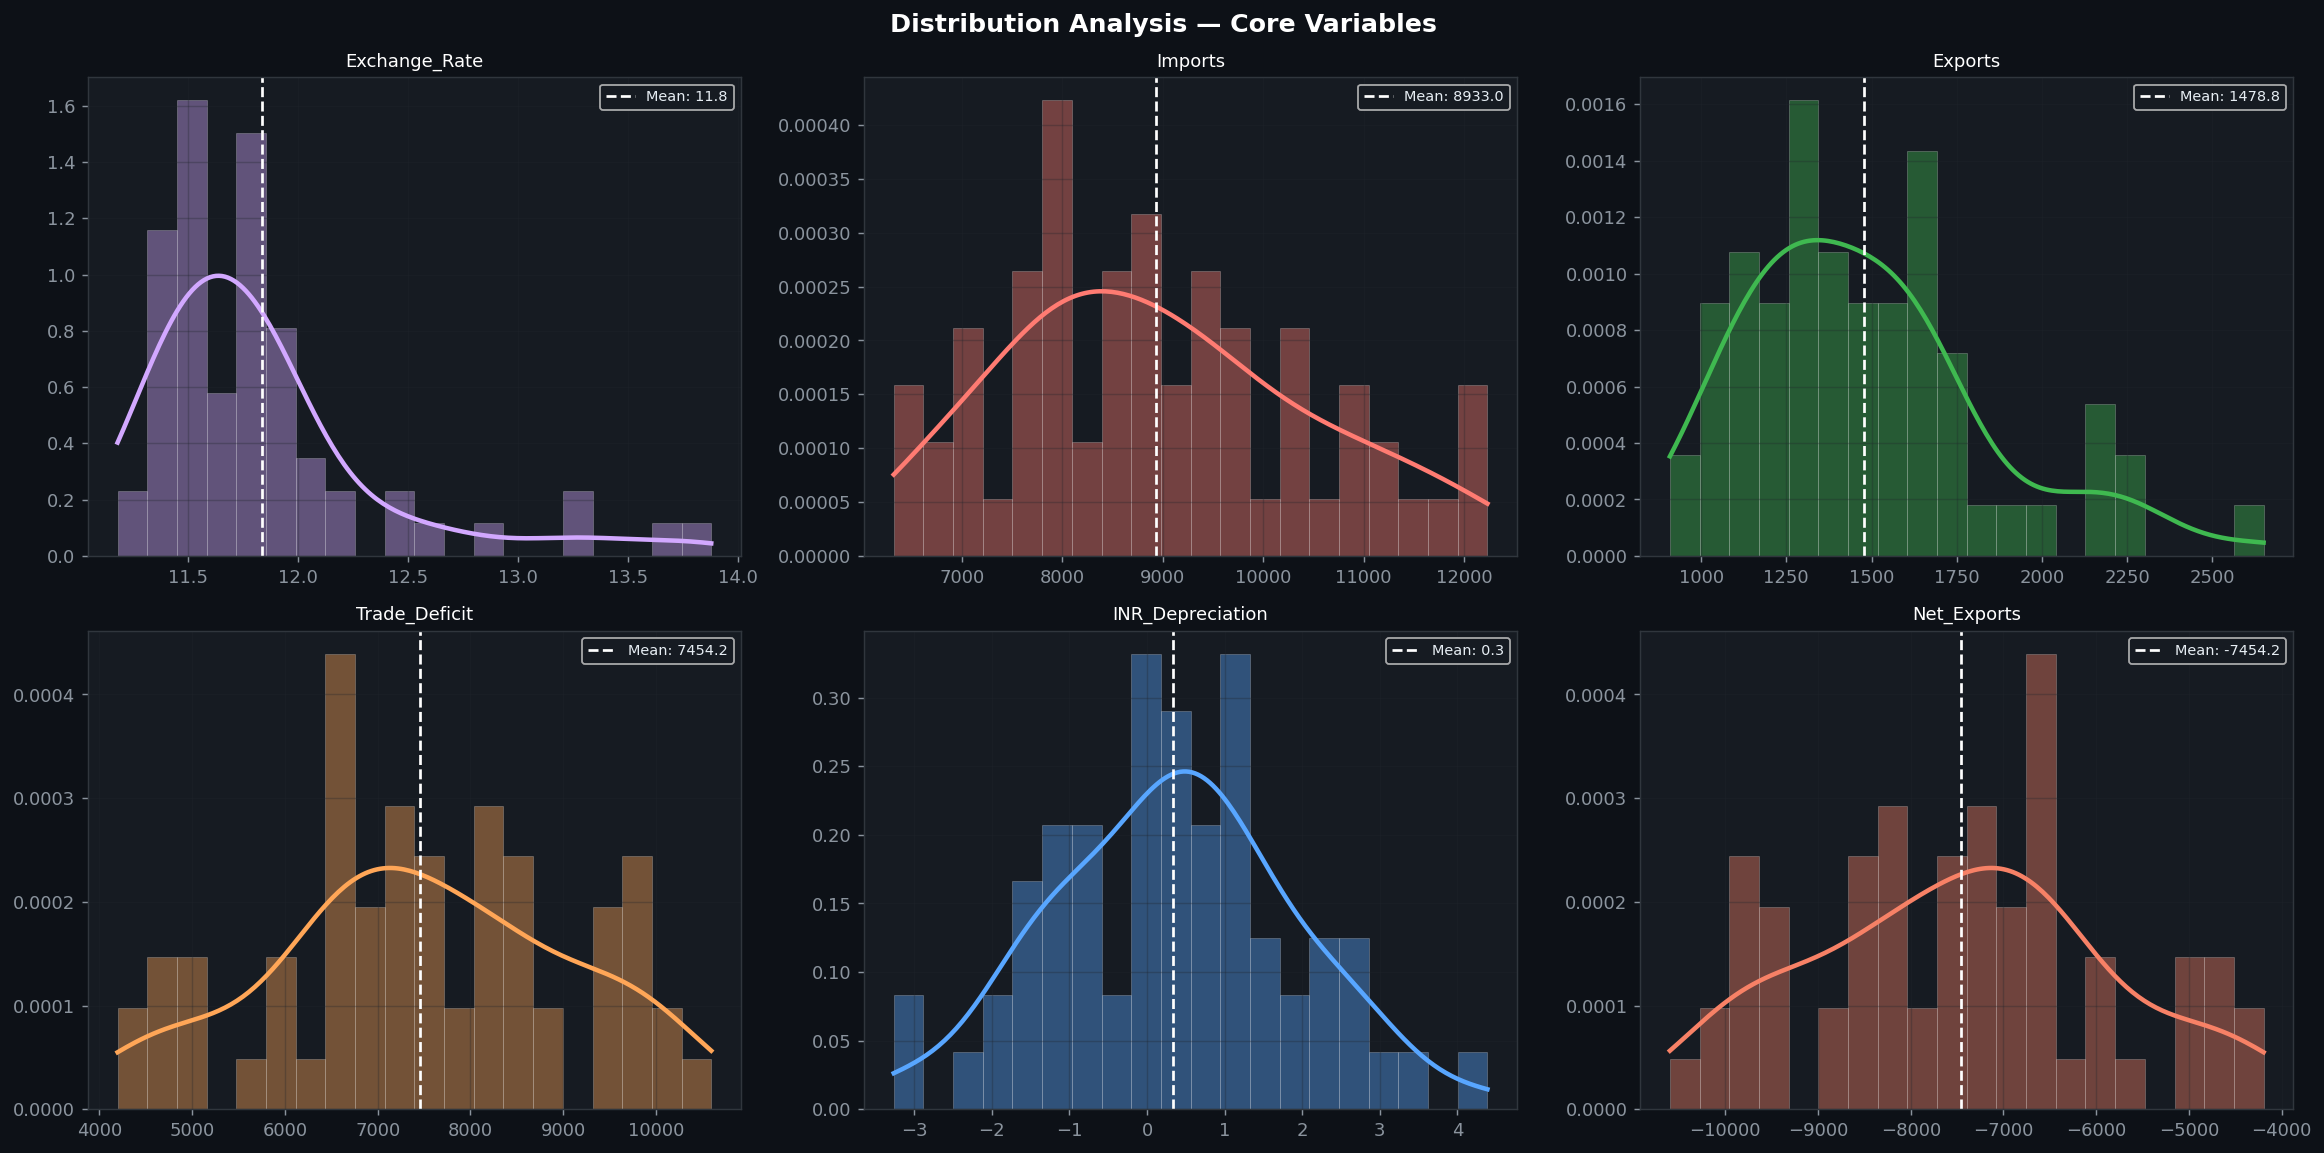

In [116]:

# ── Distribution / KDE plots ──
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.patch.set_facecolor('#0d1117')
plt.suptitle('Distribution Analysis — Core Variables', color='white', fontsize=14, fontweight='bold')

dist_vars = [
    ('Exchange_Rate','#d2a8ff'),('Imports','#ff7b72'),('Exports','#3fb950'),
    ('Trade_Deficit','#ffa657'),('INR_Depreciation','#58a6ff'),('Net_Exports','#f78166'),
]

for ax, (col, clr) in zip(axes.flatten(), dist_vars):
    data = df[col].dropna()
    ax.hist(data, bins=20, color=clr, alpha=0.4, density=True, edgecolor='white', lw=0.3)
    kde_x = np.linspace(data.min(), data.max(), 200)
    kde = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color=clr, lw=2.5)
    ax.axvline(data.mean(), color='white', lw=1.5, ls='--', label=f'Mean: {data.mean():.1f}')
    ax.set_title(col, color='white', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distributions.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


In [117]:

# ── Indexed comparison chart ──
idx_cols = ['Imports_Idx','Exports_Idx','Exchange_Rate_Idx','Trade_Deficit_Idx']
labels   = ['Imports','Exports','Exchange Rate','Trade Deficit']
colors   = ['#ff7b72','#3fb950','#d2a8ff','#ffa657']

fig = go.Figure()
for col, lbl, clr in zip(idx_cols, labels, colors):
    fig.add_trace(go.Scatter(x=df['Month'], y=df[col], name=lbl,
                             line=dict(color=clr, width=2)))

fig.add_hline(y=100, line_color='white', line_dash='dash', annotation_text='Base (Jan 2021 = 100)')
fig.update_layout(template='plotly_dark', height=500,
                  title='📊 Indexed Comparison (Base = 100, Jan 2021)',
                  plot_bgcolor='#161b22', paper_bgcolor='#0d1117')
fig.show()


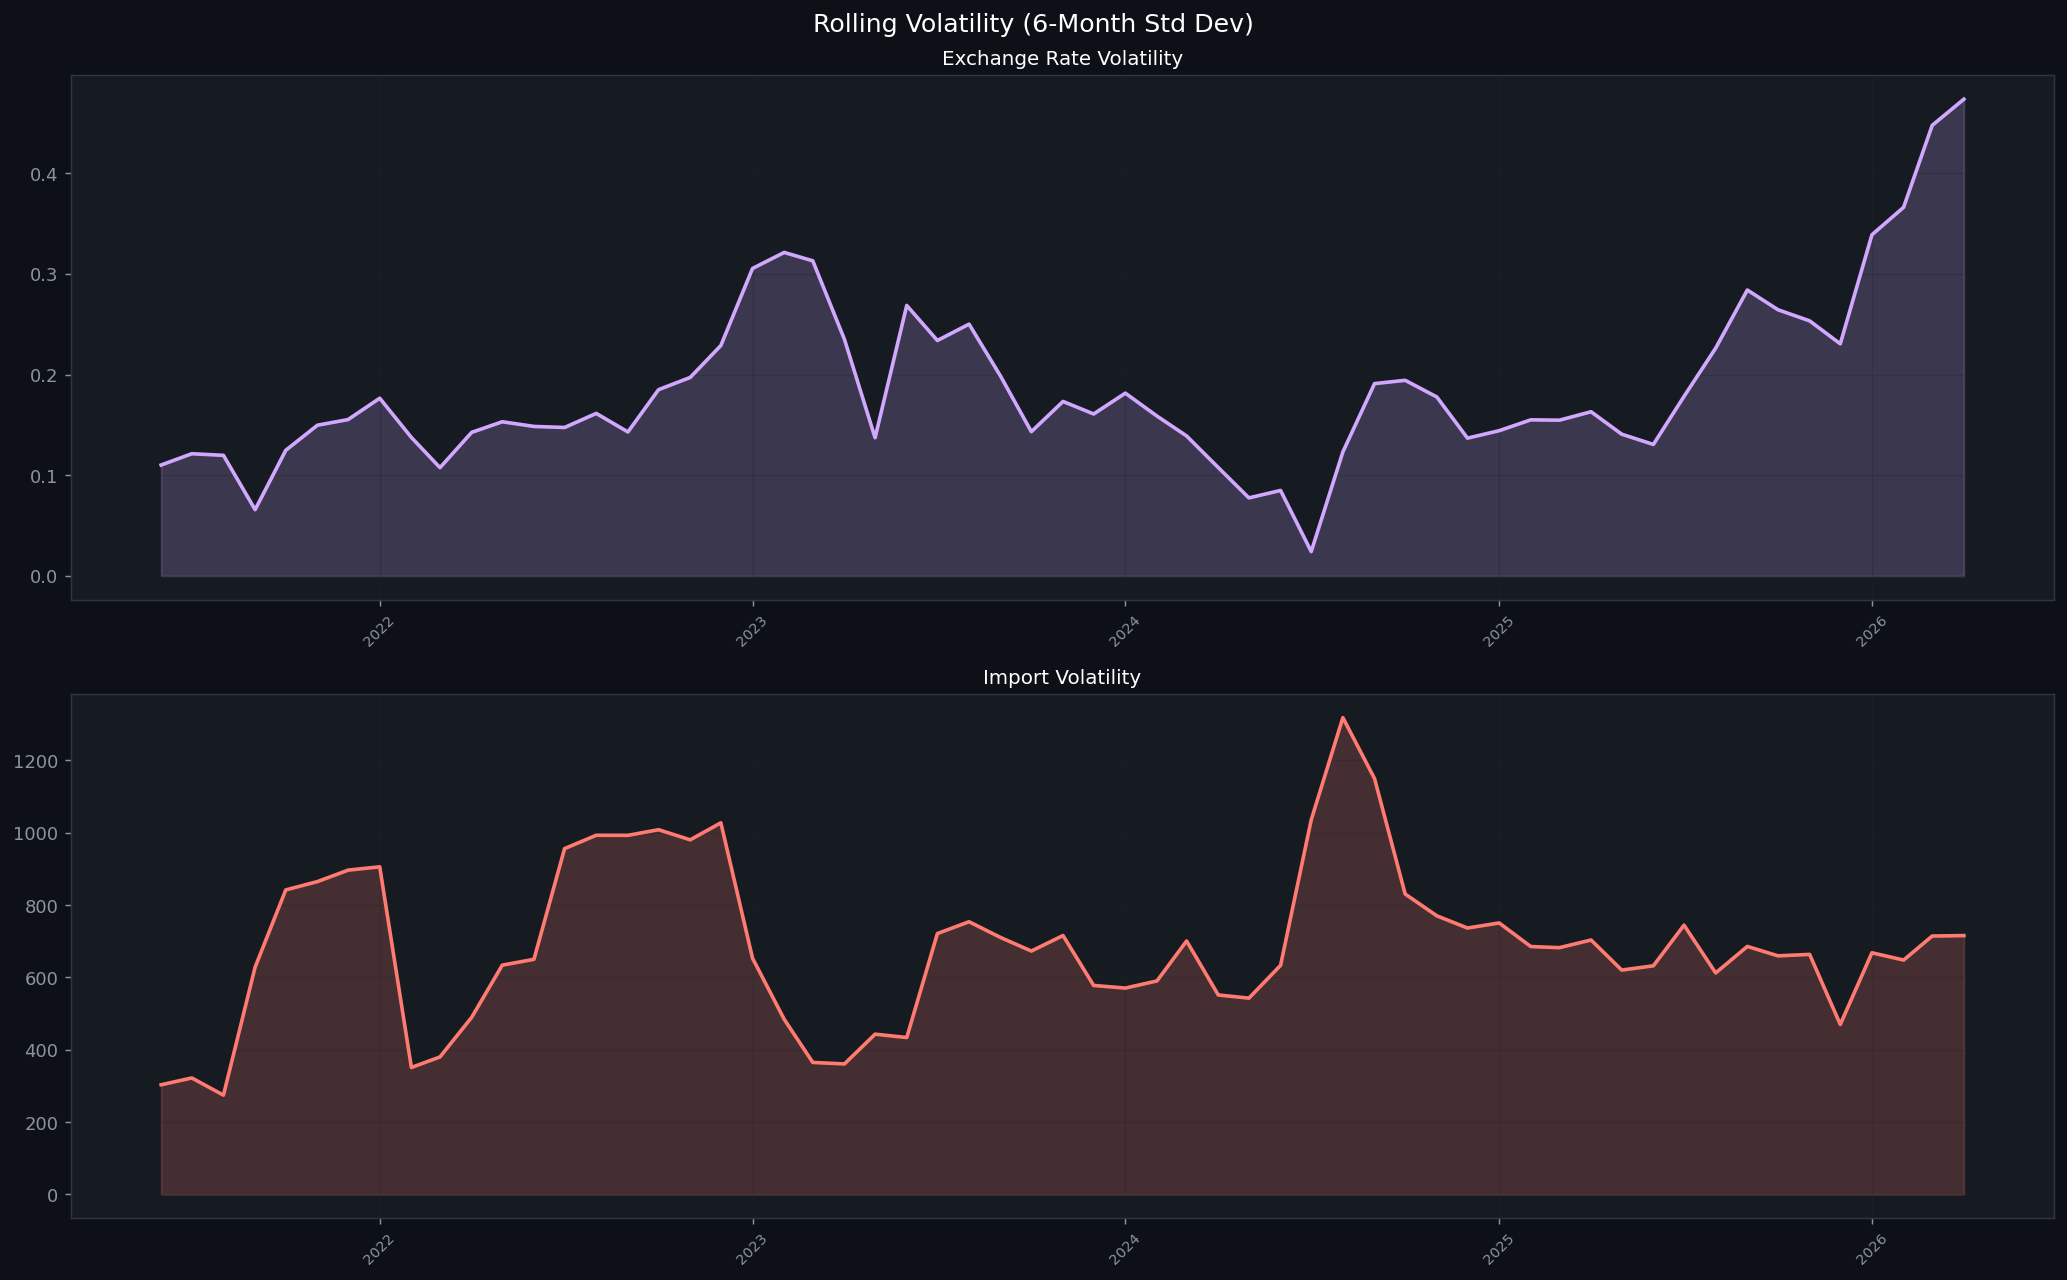

In [118]:

# ── Rolling volatility chart ──
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
plt.suptitle('Rolling Volatility (6-Month Std Dev)', color='white', fontsize=14)

for ax, (col, clr, lbl) in zip(axes, [
    ('FX_Volatility','#d2a8ff','Exchange Rate Volatility'),
    ('Import_Volatility','#ff7b72','Import Volatility'),
]):
    ax.plot(df['Month'], df[col], color=clr, lw=2)
    ax.fill_between(df['Month'], df[col], alpha=0.2, color=clr)
    ax.set_title(lbl, color='white', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('volatility.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()


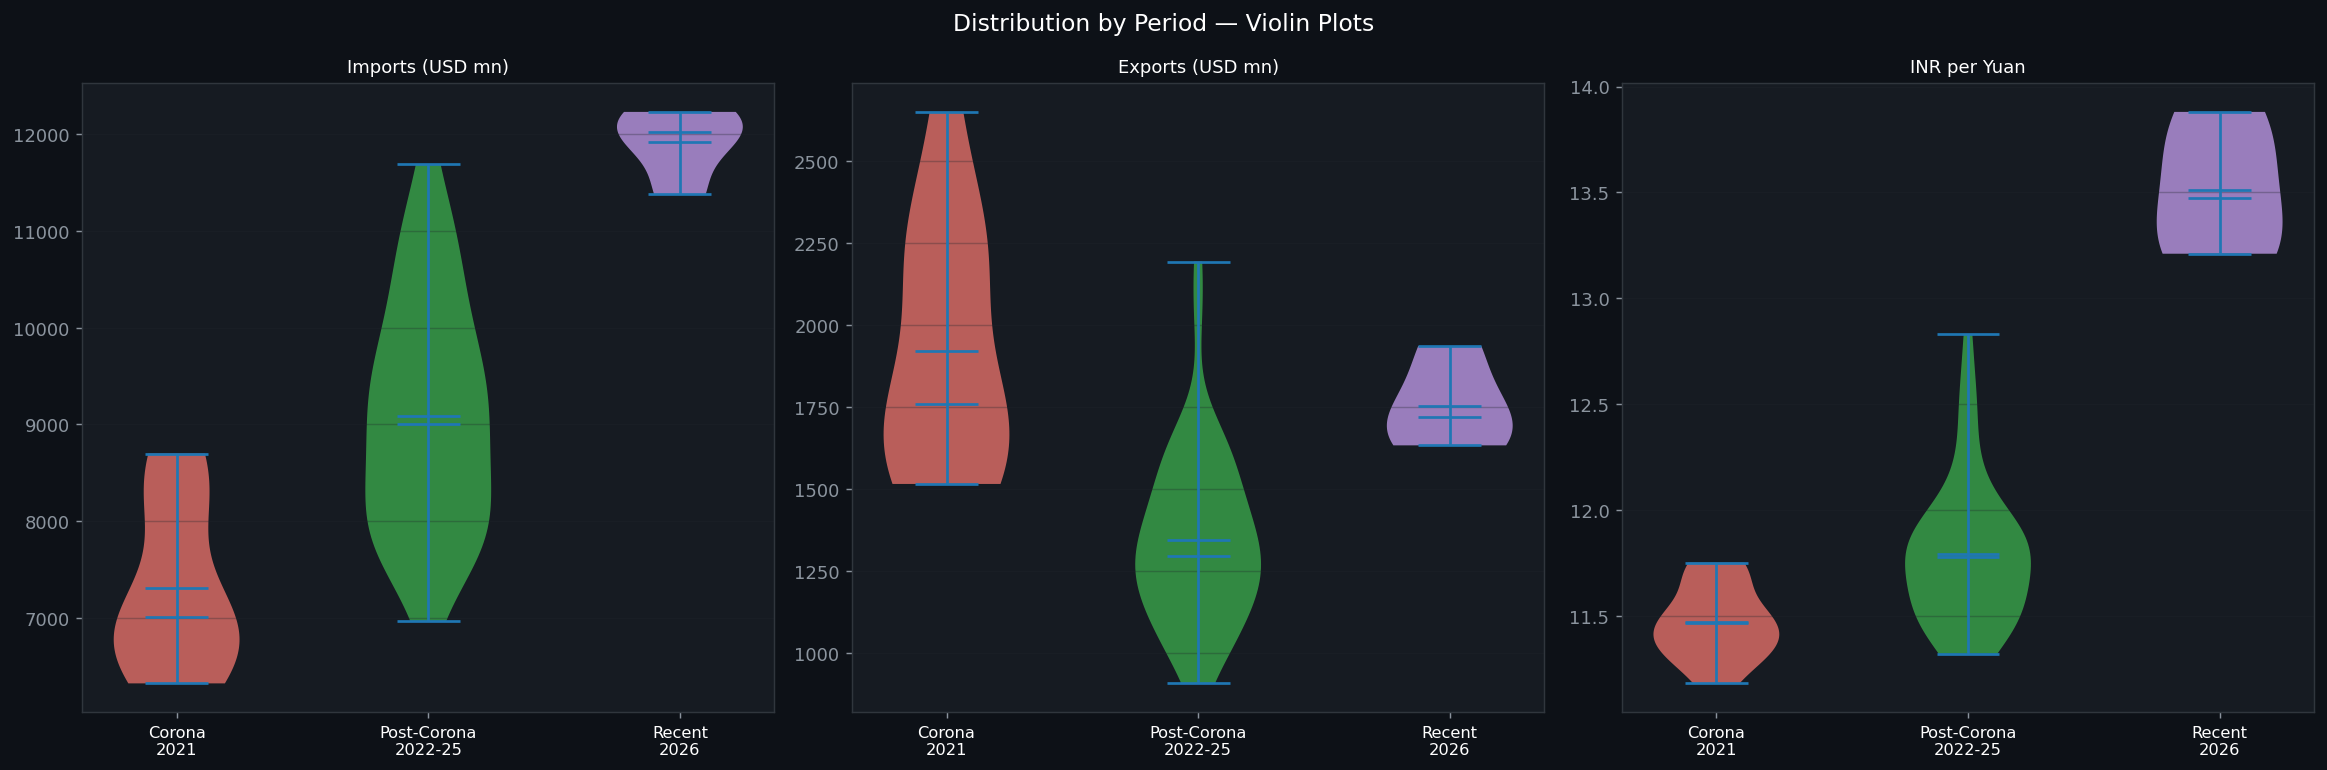

In [119]:
# ── Violin plots by period ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')
plt.suptitle('Distribution by Period — Violin Plots', color='white', fontsize=13)

for ax, (col, lbl) in zip(axes, [
    ('Imports','Imports (USD mn)'),
    ('Exports','Exports (USD mn)'),
    ('Exchange_Rate','INR per Yuan'),
]):
    period_order = ['Corona (2021)','Post-Corona (2022-25)','Recent (2026)']
    data_list = [df[df['Period']==p][col].dropna() for p in period_order]
    parts = ax.violinplot(data_list, showmeans=True, showmedians=True)

    colors_v = ['#ff7b72','#3fb950','#d2a8ff']
    for pc, clr in zip(parts['bodies'], colors_v):
        pc.set_facecolor(clr)
        pc.set_alpha(0.7)

    ax.set_xticks([1,2,3])
    # FIXED: Replaced actual line breaks with \n
    ax.set_xticklabels(['Corona\n2021', 'Post-Corona\n2022-25', 'Recent\n2026'],
                       color='white', fontsize=9)
    ax.set_title(lbl, color='white', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('violin.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## 🏁 PART 9 — Final Conclusion & Policy Implications

### Summary of Findings

| Dimension | Finding |
|-----------|---------|
| **Exchange Rate Trend** | INR depreciated ~23% vs CNY: from ₹11.31/Yuan (Jan 2021) → ₹13.88/Yuan (Apr 2026) |
| **Import Trend** | Imports rose sharply from ~USD 6.7bn → USD 12bn/month — a ~79% increase |
| **Export Trend** | Exports remained structurally weak: ~USD 1.5–2bn/month throughout |
| **Trade Deficit** | Deficit doubled: from ~USD 5.1bn → USD 10.2bn/month |
| **Depreciation Impact on Exports** | **Negligible positive effect** — exports did not respond to currency depreciation |
| **Depreciation Impact on Imports** | **Imports rose alongside depreciation**, making Chinese goods more expensive yet demand inelastic |
| **Corona Period** | Supply disruptions temporarily suppressed trade; China recovered faster, boosting its export share |
| **Post-Corona** | Deficit widened rapidly as Indian import demand surged while export capability lagged |
| **Last 4 Months (2026)** | Depreciation accelerating; imports crossing USD 12bn/month; deficit near USD 10bn/month |

---

### 📌 Economic Interpretation

1. **Depreciation has NOT improved India's export competitiveness to China.**  
   India's exports to China are largely commodity/resource-driven (iron ore, cotton, chemicals), which are price-inelastic and subject to Chinese procurement decisions rather than INR levels.

2. **Imports from China remain inelastic to currency changes.**  
   India's dependence on Chinese electronics, machinery, APIs, and intermediate goods means import demand is structurally embedded — higher prices due to weak INR are passed on rather than substituted.

3. **Trade deficit is widening at an accelerating pace.**  
   This creates sustained current account pressure and reduces India's foreign exchange reserves over time.

4. **The Marshall-Lerner condition appears to be NOT met in this bilateral context.**  
   For depreciation to improve the trade balance, the sum of export and import price elasticities must exceed 1. The data suggests both elasticities are low for India–China trade.

5. **Post-COVID structural shift:** China's rapid recovery created a supply-demand asymmetry — India needed Chinese intermediate goods for its own manufacturing recovery, while its export basket to China lacked depth.

---

### 🏛️ Policy Implications

- **Diversify import sources:** Reduce dependence on Chinese intermediates via PLI (Production-Linked Incentive) schemes and domestic manufacturing push.
- **Develop export capabilities to China:** Target pharmaceuticals, IT services, specialty chemicals, and agro-products with bilateral trade agreements.
- **Currency management:** RBI intervention alone cannot resolve structural deficits; industrial policy must complement exchange rate management.
- **Monitor recent acceleration:** The sharp INR/CNY move in 2026 (to 13.65–13.88) demands close surveillance of import bills and CAD widening.
- **Invest in import substitution:** Especially in electronics and APIs where India pays a structural premium to China.

---

> *This analysis was conducted using monthly trade data (Jan 2021 – Apr 2026) covering 64 observations. Statistical findings are robust across Pearson, Spearman, OLS regression, and ADF tests. Economic conclusions align with established theories of currency-trade dynamics, adjusted for bilateral structural factors.*
